# Playground for LLMs

Llama 3.2 1B Instruct model

In [ ]:
from src.llm import LLM

model = LLM(model_id="meta-llama/Llama-3.2-1B-Instruct")

prompt = ["What is the capital of Italy?"]
response = model.generate_batch(prompt)

print(response[0][0])

Llama 3.2 70B Chat model with 8-bit quantization

In [ ]:
from src.llm import LLM

model = LLM(model_id="meta-llama/Llama-2-70b-chat-hf")

prompt = ["What is the capital of Israel?"]
response = model.generate_batch(prompt)

print(response[0][0])

In [ ]:
from src.llm import LLM

model = LLM(model_id="google/gemma-3-4b-it")

prompt = ["What is the capital of Israel?"]
response = model.generate_batch(prompt)

print(response[0][0])

In [ ]:
import json 
import random 

with open("./llms.json", 'r') as f:
    available_llms = json.load(f)["llms"]

llms = random.sample(available_llms, 2)
names = [llm["name"] for llm in available_llms]
shortnames = [llm["shortname"] for llm in available_llms]

print(names)
print(shortnames)

In [ ]:
available_llms

In [ ]:
# import os
# import shutil

# def merge_directories(dir1, dir2, output_dir):
#     """
#     Merge two directories into a new one.
#     - All files/dirs from dir1 are copied.
#     - Files from dir2 are copied only if they don't already exist in dir1.
#     - Directories are merged recursively.

#     Args:
#         dir1 (str): Path to the first directory.
#         dir2 (str): Path to the second directory.
#         output_dir (str): Path where the merged directory will be created.
#     """
#     os.makedirs(output_dir, exist_ok=True)

#     # Copy everything from dir1 (takes precedence)
#     for root, _, files in os.walk(dir1):
#         rel_path = os.path.relpath(root, dir1)
#         target_root = os.path.join(output_dir, rel_path)
#         os.makedirs(target_root, exist_ok=True)

#         for file in files:
#             src_file = os.path.join(root, file)
#             dst_file = os.path.join(target_root, file)
#             shutil.copy2(src_file, dst_file)

#     # Copy from dir2 only if not already present
#     for root, _, files in os.walk(dir2):
#         rel_path = os.path.relpath(root, dir2)
#         target_root = os.path.join(output_dir, rel_path)
#         os.makedirs(target_root, exist_ok=True)

#         for file in files:
#             dst_file = os.path.join(target_root, file)
#             if not os.path.exists(dst_file):  # keep dir1’s version if conflict
#                 src_file = os.path.join(root, file)
#                 shutil.copy2(src_file, dst_file)

#     print(f"Merged contents into: {output_dir}")
    
# merge_directories("./logs/", "./tmp/logs/", "./lepedro/")

In [ ]:
import glob
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
import re
from collections import defaultdict
from pathlib import Path


def sample(dict: dict, n: int) -> dict:
    if not dict:
        return dict
    
    # Keys and weights
    elements = np.array(list(dict.keys()))
    weights = np.array(list(dict.values()), dtype=float)

    # Normalize weights to probabilities
    probabilities = weights / weights.sum()

    # Sample with replacement
    samples = np.random.choice(elements, size=n, p=probabilities)

    # Count occurrences and convert back to dictionary
    sampled_dict = {
        str(key): int(count) for key, count in zip(*np.unique(samples, return_counts=True))
    }

    return sampled_dict

def get_family(model_name):
    return model_name.split("/")[1] if model_name.startswith("/") else model_name.split("/")[0]

def get_color(model_name, models_in_family):
    family = get_family(model_name)
    cmap = family_colormaps[family]
    idx = models_in_family.index(model_name)
    n = len(models_in_family)
    return cmap(0.3 + 0.6 * idx / (n - 1 if n > 1 else 1))  # spaced shades

def get_available_models(model_names, required_files):
    working_model_names = []
    corrupted_model_names = {}
    required = set(required_files)
    for m in model_names:
        files = set(glob.glob(f"./results{m}/*"))
        files = set([f.split('/')[-1] for f in files])
        missing_files = required.difference(files)
        if missing_files != set():
            corrupted_model_names[m] = required.difference(files)
        else:
            working_model_names.append(m)
            
    return working_model_names

# Define families and assign colormaps
family_colormaps = {
    "meta-llama": cm.Blues,
    "google": cm.Reds,
    "microsoft": cm.Greens,
    "Qwen": cm.Purples,
    "deepseek-ai": cm.Oranges,
}

# Files required to run all the experiments
required_files = [
    "amsterdam_problem-coordinate.jsonl",
    "amsterdam_problem-guess.jsonl",
    "amsterdam_problem-pick.jsonl",
    "nottingham_problem-coordinate.jsonl",
    "nottingham_problem-guess.jsonl",
    "nottingham_problem-pick.jsonl"
]

# Families of models we test: each corresponds to a folder in ./results
models = ["meta-llama"]
num_samples = 64

# Datasets and tasks (we name them labels)
dataset_names = ["amsterdam", "nottingham"]
labels = ["pick", "guess", "coordinate"]

# Matplotlib config
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Times New Roman'

# Savedir (creation)
SAVEDIR = "./plots"
COORDINATION_INDEX_FOLDER = "/coordination-index/sample/llama"
BEST_MODELS_COORDINATION_INDEX_FOLDER = "/coordination-index-best/sample/llama"
BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER = "/coordination-index-best-merge/sample/llama"
BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER_SIDE = "/coordination-index-best-merge-side/sample/llama"


for folder in [COORDINATION_INDEX_FOLDER, 
               BEST_MODELS_COORDINATION_INDEX_FOLDER,
               BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER,
               BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER_SIDE]:
    if not os.path.exists(Path(SAVEDIR + folder)):
        print("Creating path: ", Path(SAVEDIR + folder))
        os.makedirs(Path(SAVEDIR + folder))
    
if __name__ == "__main__":

    # Collect the names of the folders inside each "model"
    model_names = []
    for m in models:
        for model_path in next(os.walk("./results/" + m)):
            if "./results/" in model_path:
                prefix = model_path
                continue
            model_names.extend([prefix.split("./results")[1] + "/" + llm for llm in model_path])

    print("--- Available Models ---")
    for i,m in enumerate(model_names):
        print(f"{i+1}. {m}")
        
    model_names = get_available_models(model_names, required_files)
    
    # Sort by model-size
    model_by_size = {}
    for m in model_names:
        match = re.search(r"-([0-9]+)([B])(?:-|$)", m, re.DOTALL)
        size = int(match.group(1).strip())
        model_by_size[m] = size
    
    model_by_size = {k: v for k, v in sorted(model_by_size.items(), key=lambda item: item[1])}
    model_names = list(model_by_size.keys())

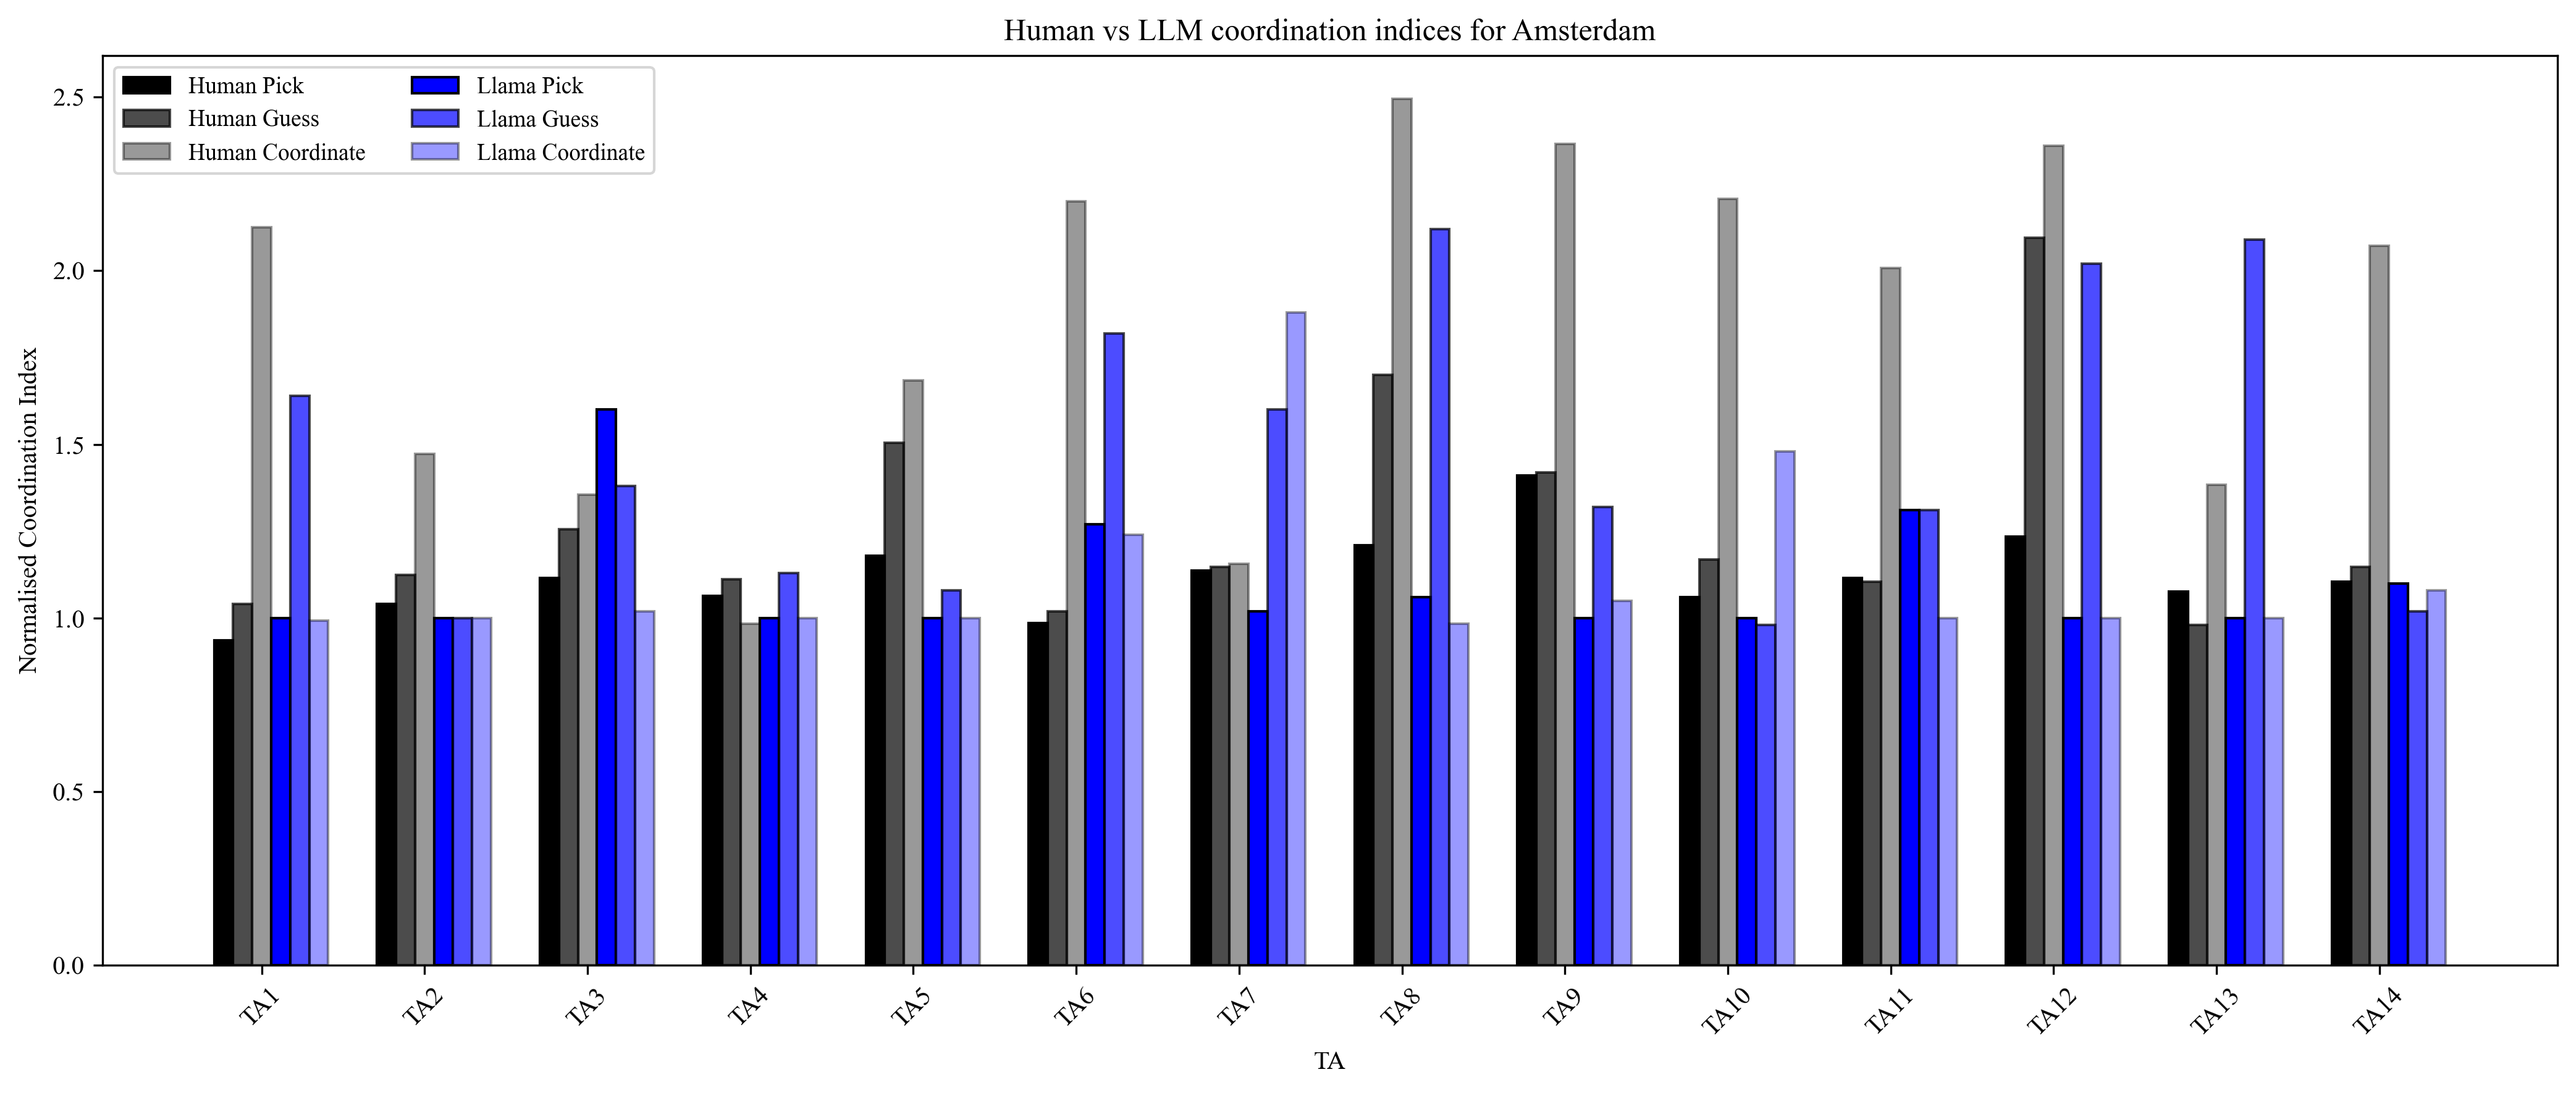

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Human data
human_data = {'TA1': {'pick': 0.935, 'guess': 1.04, 'coordinate': 2.125},
            'TA2': {'pick': 1.04, 'guess': 1.124, 'coordinate': 1.472},
            'TA3': {'pick': 1.115, 'guess': 1.255, 'coordinate': 1.355},
            'TA4': {'pick': 1.064, 'guess': 1.112, 'coordinate': 0.984},
            'TA5': {'pick': 1.18, 'guess': 1.504, 'coordinate': 1.684},
            'TA6': {'pick': 0.985, 'guess': 1.02, 'coordinate': 2.2},
            'TA7': {'pick': 1.136, 'guess': 1.148, 'coordinate': 1.156},
            'TA8': {'pick': 1.21, 'guess': 1.7, 'coordinate': 2.495},
            'TA9': {'pick': 1.41, 'guess': 1.42, 'coordinate': 2.365},
            'TA10': {'pick': 1.06, 'guess': 1.168, 'coordinate': 2.208},
            'TA11': {'pick': 1.116, 'guess': 1.104, 'coordinate': 2.008},
            'TA12': {'pick': 1.235, 'guess': 2.095, 'coordinate': 2.36},
            'TA13': {'pick': 1.076, 'guess': 0.98, 'coordinate': 1.384},
            'TA14': {'pick': 1.104, 'guess': 1.148, 'coordinate': 2.072}}

# LLM data
llm_data = {'TA1': {'pick': 1.0, 'guess': 1.64, 'coordinate': 0.9931},
            'TA2': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0},
            'TA3': {'pick': 1.6, 'guess': 1.38, 'coordinate': 1.0198},
            'TA4': {'pick': 1.0, 'guess': 1.13, 'coordinate': 1.0},
            'TA5': {'pick': 1.0, 'guess': 1.08, 'coordinate': 1.0},
            'TA6': {'pick': 1.27, 'guess': 1.82, 'coordinate': 1.24},
            'TA7': {'pick': 1.02, 'guess': 1.6, 'coordinate': 1.88},
            'TA8': {'pick': 1.06, 'guess': 2.12, 'coordinate': 0.9841},
            'TA9': {'pick': 1.0, 'guess': 1.32, 'coordinate': 1.05},
            'TA10': {'pick': 1.0, 'guess': 0.98, 'coordinate': 1.48},
            'TA11': {'pick': 1.31, 'guess': 1.31, 'coordinate': 1.0},
            'TA12': {'pick': 1.0, 'guess': 2.02, 'coordinate': 1.0},
            'TA13': {'pick': 1.0, 'guess': 2.09, 'coordinate': 1.0},
            'TA14': {'pick': 1.1, 'guess': 1.02, 'coordinate': 1.08}}

TAs = list(human_data.keys())
tasks = ['pick', 'guess', 'coordinate']

x = np.arange(len(TAs))  # the label locations
width = 0.35  # width of bar group

fig, ax = plt.subplots(figsize=(14,6))

# Human bars (black)
human_vals = np.array([[human_data[ta][task] for task in tasks] for ta in TAs])
ax.bar(x - width/2, human_vals[:,0], width/3, color='black', edgecolor='black', label='Human Pick')
ax.bar(x - width/2 + width/3, human_vals[:,1], width/3, color='black', edgecolor='black', alpha=0.7, label='Human Guess')
ax.bar(x - width/2 + 2*width/3, human_vals[:,2], width/3, color='black', edgecolor='black', alpha=0.4, label='Human Coordinate')

# LLM bars (blue)
llm_vals = np.array([[llm_data[ta][task] for task in tasks] for ta in TAs])
ax.bar(x + width/2, llm_vals[:,0], width/3, color='blue', edgecolor='black', label='Llama Pick')
ax.bar(x + width/2 + width/3, llm_vals[:,1], width/3, color='blue', edgecolor='black', alpha=0.7, label='Llama Guess')
ax.bar(x + width/2 + 2*width/3, llm_vals[:,2], width/3, color='blue', edgecolor='black', alpha=0.4, label='Llama Coordinate')

# Labels and formatting
ax.set_ylabel('Normalised Coordination Index')
ax.set_xlabel('TA')
ax.set_title('Human vs LLM coordination indices for Amsterdam')
ax.set_xticks(x + width/6)
ax.set_xticklabels(TAs)
ax.legend(ncol=2, fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


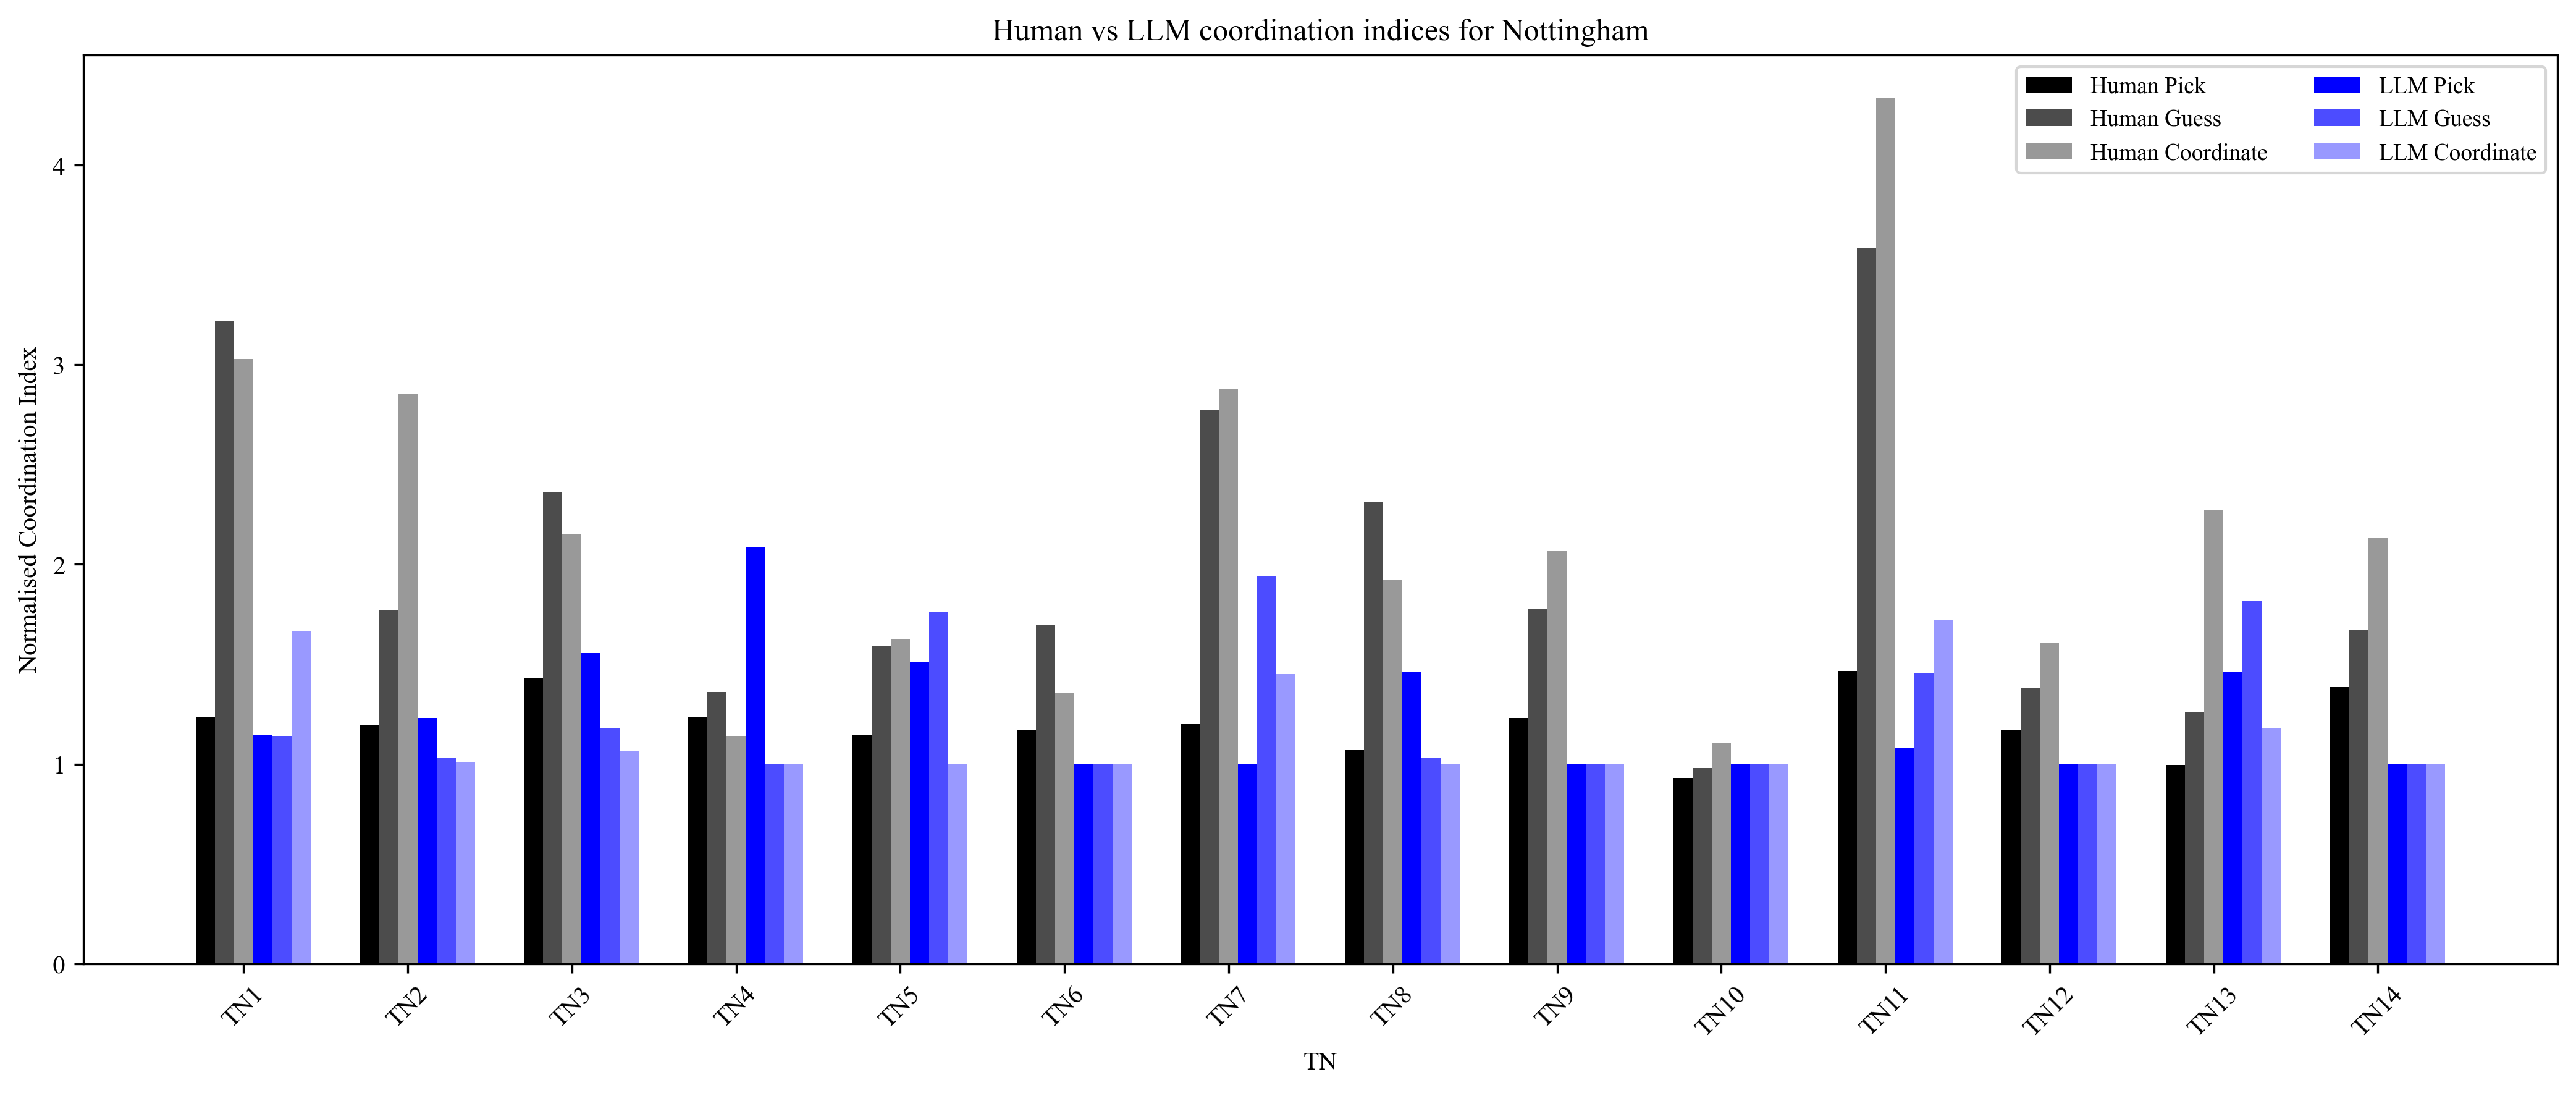

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Human data for Nottingham
human_data = {'TN1': {'pick': 1.235, 'guess': 3.22, 'coordinate': 3.03},
            'TN2': {'pick': 1.195, 'guess': 1.77, 'coordinate': 2.855},
            'TN3': {'pick': 1.43, 'guess': 2.36, 'coordinate': 2.15},
            'TN4': {'pick': 1.235, 'guess': 1.36, 'coordinate': 1.1425},
            'TN5': {'pick': 1.145, 'guess': 1.59, 'coordinate': 1.625},
            'TN6': {'pick': 1.17, 'guess': 1.695, 'coordinate': 1.355},
            'TN7': {'pick': 1.2, 'guess': 2.775, 'coordinate': 2.88},
            'TN8': {'pick': 1.07, 'guess': 2.315, 'coordinate': 1.92},
            'TN9': {'pick': 1.23, 'guess': 1.78, 'coordinate': 2.065},
            'TN10': {'pick': 0.93, 'guess': 0.98, 'coordinate': 1.105},
            'TN11': {'pick': 1.465, 'guess': 3.585, 'coordinate': 4.335},
            'TN12': {'pick': 1.17, 'guess': 1.38, 'coordinate': 1.61},
            'TN13': {'pick': 0.995, 'guess': 1.26, 'coordinate': 2.275},
            'TN14': {'pick': 1.385, 'guess': 1.675, 'coordinate': 2.13}}

# LLM data for Nottingham
llm_data = {'TN1': {'pick': 1.144841, 'guess': 1.07, 'coordinate': 1.49},
            'TN2': {'pick': 1.77, 'guess': 0.98, 'coordinate': 1.01},
            'TN3': {'pick': 1.555556, 'guess': 1.34, 'coordinate': 1.01},
            'TN4': {'pick': 2.31, 'guess': 1.0, 'coordinate': 1.0},
            'TN5': {'pick': 1.56, 'guess': 1.31, 'coordinate': 1.0},
            'TN6': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0},
            'TN7': {'pick': 1.0, 'guess': 1.8, 'coordinate': 1.28},
            'TN8': {'pick': 1.51, 'guess': 1.15, 'coordinate': 1.0},
            'TN9': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0},
            'TN10': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0},
            'TN11': {'pick': 1.02, 'guess': 1.83, 'coordinate': 1.65},
            'TN12': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0},
            'TN13': {'pick': 1.76, 'guess': 1.82, 'coordinate': 1.38},
            'TN14': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0}}

TAs = list(human_data.keys())
tasks = ['pick', 'guess', 'coordinate']

x = np.arange(len(TAs))  # the label locations
width = 0.35  # width of bar group

fig, ax = plt.subplots(figsize=(14,6))

# Human bars (black)
human_vals = np.array([[human_data[ta][task] for task in tasks] for ta in TAs])
ax.bar(x - width/2, human_vals[:,0], width/3, color='black',edgecolor='black', label='Human Pick')
ax.bar(x - width/2 + width/3, human_vals[:,1], width/3, color='black', edgecolor='black', alpha=0.7, label='Human Guess')
ax.bar(x - width/2 + 2*width/3, human_vals[:,2], width/3, color='black',edgecolor='black', alpha=0.4, label='Human Coordinate')

# LLM bars (blue)
llm_vals = np.array([[llm_data[ta][task] for task in tasks] for ta in TAs])
ax.bar(x + width/2, llm_vals[:,0], width/3, color='blue',edgecolor='black', label='Llama Pick')
ax.bar(x + width/2 + width/3, llm_vals[:,1], width/3, color='blue', edgecolor='black', alpha=0.7, label='Llama Guess')
ax.bar(x + width/2 + 2*width/3, llm_vals[:,2], width/3, color='blue',edgecolor='black', alpha=0.4, label='Llama Coordinate')

# Labels and formatting
ax.set_ylabel('Normalised Coordination Index')
ax.set_xlabel('TN')
ax.set_title('Human vs LLM coordination indices for Nottingham')
ax.set_xticks(x + width/6)
ax.set_xticklabels(TAs)
ax.legend(ncol=2, fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [3]:
import glob
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
import re
from collections import defaultdict
from pathlib import Path

def sample(d: dict, n: int, replacement: bool = True) -> dict:
    
    if replacement:
        if not d or n >= sum(d.values()):
            return d
    
    # Create the full population list
    population = []
    for key, count in d.items():
        population.extend([key] * count)
    
    # Adjust n for no-replacement
    if not replacement and n > len(population):
        n = len(population)
    
    # Sample from the population
    samples = np.random.choice(population, size=n, replace=replacement)
    
    # Count occurrences
    result = {}
    for s in samples:
        result[str(s)] = result.get(s, 0) + 1
    
    return result

def get_family(model_name):
    return model_name.split("/")[1] if model_name.startswith("/") else model_name.split("/")[0]

def get_color(model_name, models_in_family):
    family = get_family(model_name)
    cmap = family_colormaps[family]
    idx = models_in_family.index(model_name)
    n = len(models_in_family)
    return cmap(0.3 + 0.6 * idx / (n - 1 if n > 1 else 1))  # spaced shades

def get_available_models(model_names, required_files):
    working_model_names = []
    corrupted_model_names = {}
    required = set(required_files)
    for m in model_names:
        files = set(glob.glob(f"./results{m}/*"))
        files = set([f.split('/')[-1] for f in files])
        missing_files = required.difference(files)
        if missing_files != set():
            corrupted_model_names[m] = required.difference(files)
        else:
            working_model_names.append(m)
            
    return working_model_names

# Define families and assign colormaps
family_colormaps = {
    "meta-llama": cm.Blues,
    "google": cm.Reds,
    "microsoft": cm.Greens,
    "Qwen": cm.Purples,
    "deepseek-ai": cm.Oranges,
}

# Files required to run all the experiments
required_files = [
    "amsterdam_problem-coordinate.jsonl",
    "amsterdam_problem-guess.jsonl",
    "amsterdam_problem-pick.jsonl",
    "nottingham_problem-coordinate.jsonl",
    "nottingham_problem-guess.jsonl",
    "nottingham_problem-pick.jsonl"
]

# Families of models we test: each corresponds to a folder in ./results
models = ["meta-llama"]
num_samples = 1000
sample_with_replacement = False

# Datasets and tasks (we name them labels)
dataset_names = ["amsterdam", "nottingham"]
labels = ["pick", "guess", "coordinate"]

# Matplotlib config
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Times New Roman'

# Savedir (creation)
SAVEDIR = "./plots"
sample_folder = ('sample-with-replacement' if sample_with_replacement else 'sample-without-replacement')
COORDINATION_INDEX_FOLDER = f"/coordination-index/{sample_folder}/llama"
BEST_MODELS_COORDINATION_INDEX_FOLDER = f"/coordination-index-best/{sample_folder}/llama"
BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER = f"/coordination-index-best-merge/{sample_folder}/llama"
BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER_SIDE = f"/coordination-index-best-merge-side/{sample_folder}/llama"


for folder in [COORDINATION_INDEX_FOLDER, 
               BEST_MODELS_COORDINATION_INDEX_FOLDER,
               BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER,
               BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER_SIDE]:
    if not os.path.exists(Path(SAVEDIR + folder)):
        print("Creating path: ", Path(SAVEDIR + folder))
        os.makedirs(Path(SAVEDIR + folder))
    
if __name__ == "__main__":

    # Collect the names of the folders inside each "model"
    model_names = []
    for m in models:
        for model_path in next(os.walk("./results/" + m)):
            if "./results/" in model_path:
                prefix = model_path
                continue
            model_names.extend([prefix.split("./results")[1] + "/" + llm for llm in model_path])

    print("--- Available Models ---")
    for i,m in enumerate(model_names):
        print(f"{i+1}. {m}")
        
    model_names = get_available_models(model_names, required_files)
    
    # Sort by model-size
    model_by_size = {}
    for m in model_names:
        match = re.search(r"-([0-9]+)([B])(?:-|$)", m, re.DOTALL)
        size = int(match.group(1).strip())
        model_by_size[m] = size
    
    model_by_size = {k: v for k, v in sorted(model_by_size.items(), key=lambda item: item[1])}
    model_names = list(model_by_size.keys())


--- Available Models ---
1. /meta-llama/Meta-Llama-3-8B-Instruct
2. /meta-llama/Llama-3.2-1B-Instruct
3. /meta-llama/Llama-3.1-8B-Instruct
4. /meta-llama/Meta-Llama-3-70B-Instruct
5. /meta-llama/Llama-3.2-3B-Instruct
6. /meta-llama/Llama-3.1-70B-Instruct
7. /meta-llama/Llama-3.3-70B-Instruct


Dataset: amsterdam
Label: pick
14
{'jogging': 8, 'running': 6, 'walking': 76}
[1.770287141073658, 1.66541822721598, 1.6779026217228465, 2.581772784019975, 1.8239700374531835, 1.2883895131086143, 1.682896379525593, 1.3682896379525593, 1.7016229712858926, 2.3645443196004994, 1.752808988764045, 2.4132334581772783, 1.7328339575530587, 3.6117353308364546]
14


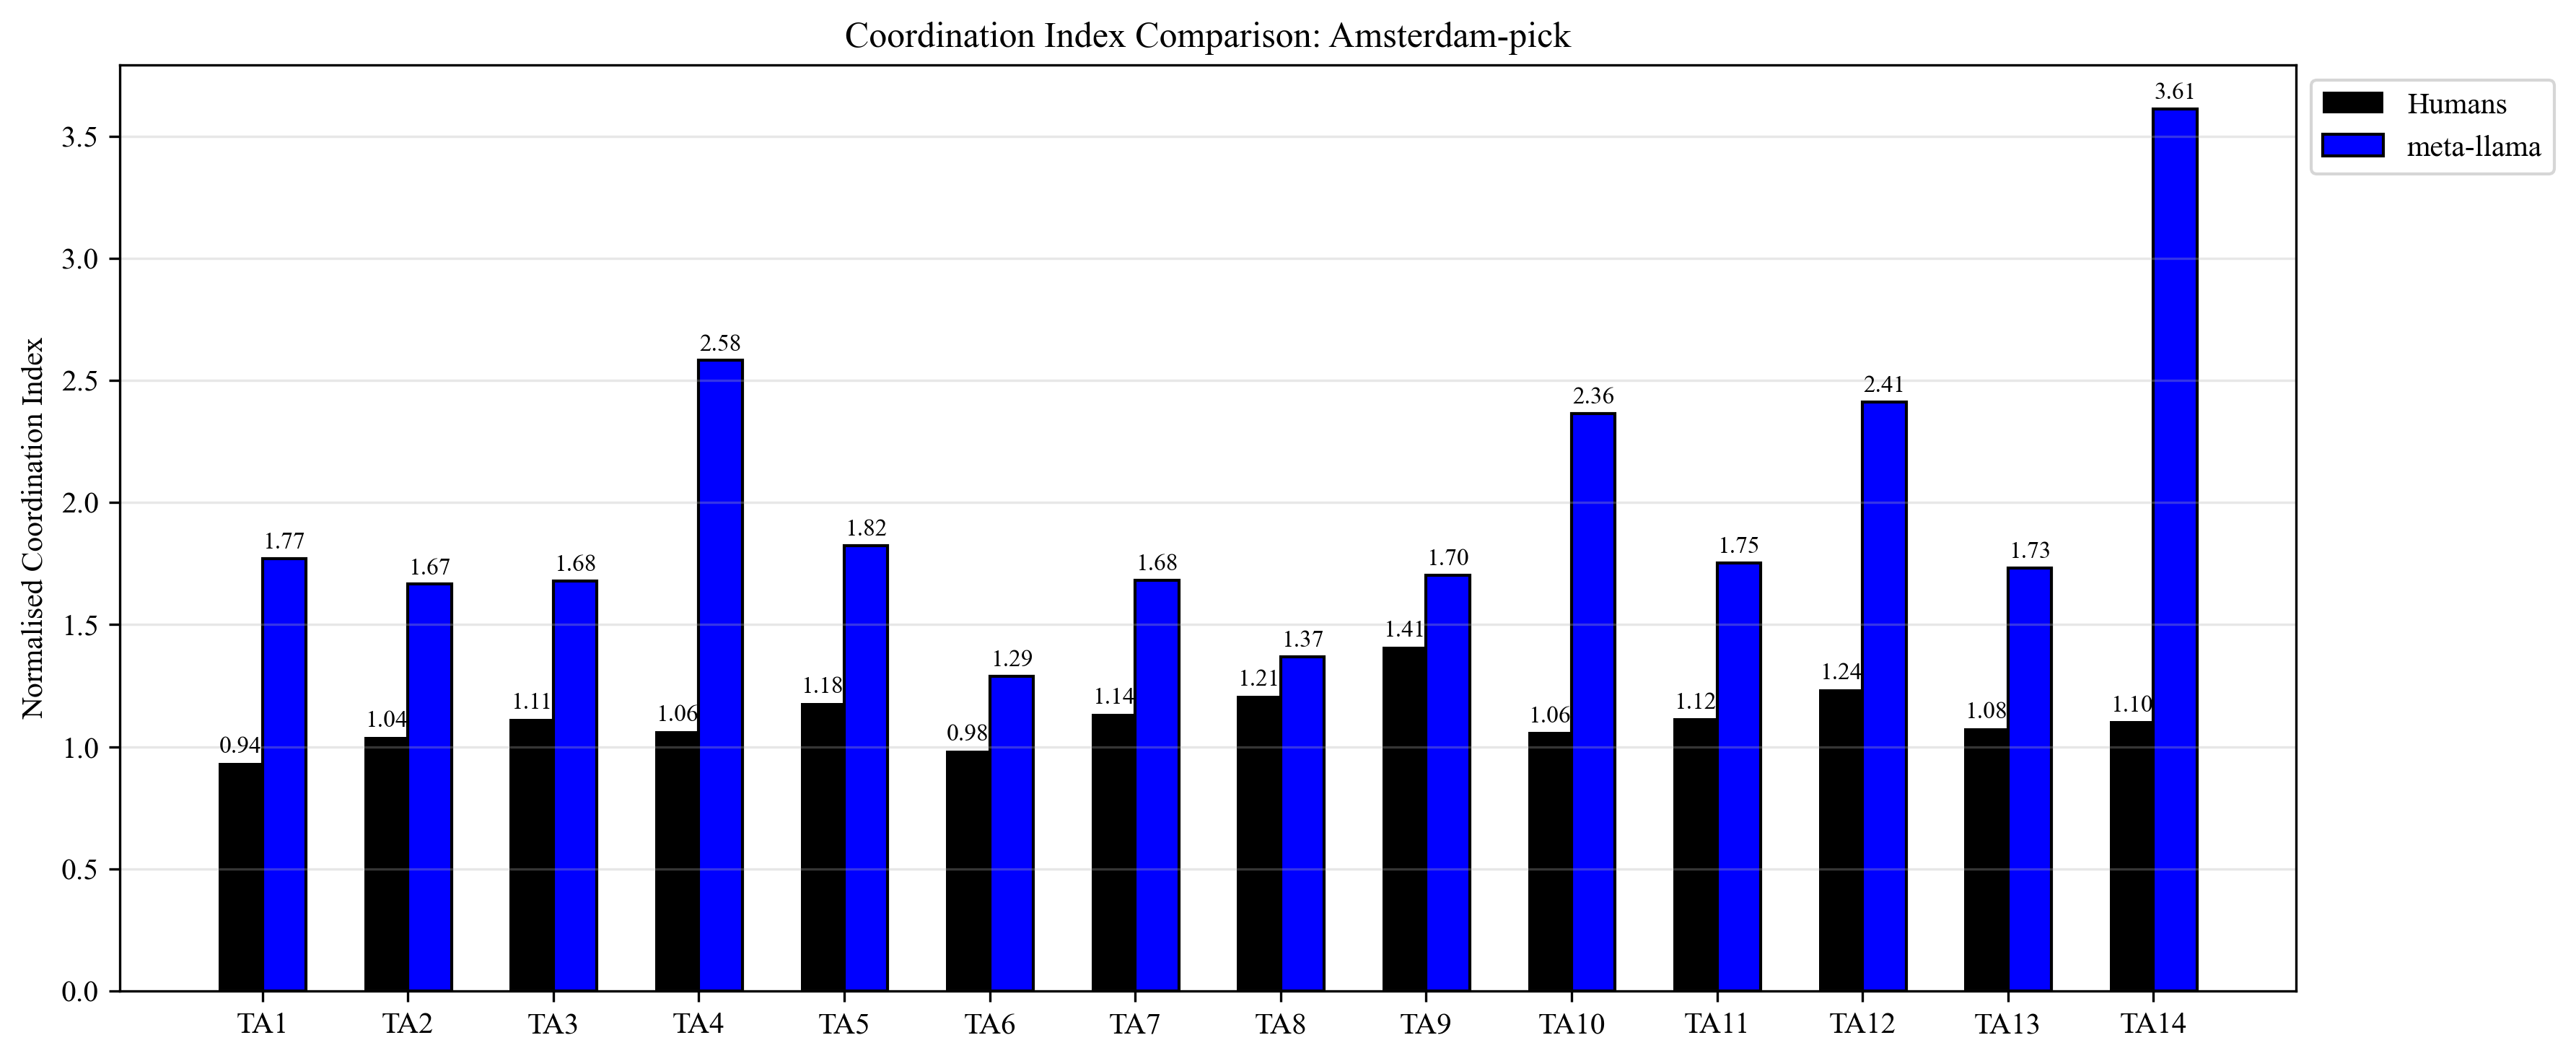

Label: guess
14
{'walking': 58, 'sitting': 26, 'running': 2, 'jogging': 2}
[2.0574282147315857, 2.0324594257178528, 2.634207240948814, 3.5168539325842696, 3.521847690387016, 2.0187265917602994, 2.1797752808988764, 1.937578027465668, 1.6903870162297128, 2.791510611735331, 2.1897344228804902, 2.644194756554307, 2.5068664169787764, 2.586206896551724]
14


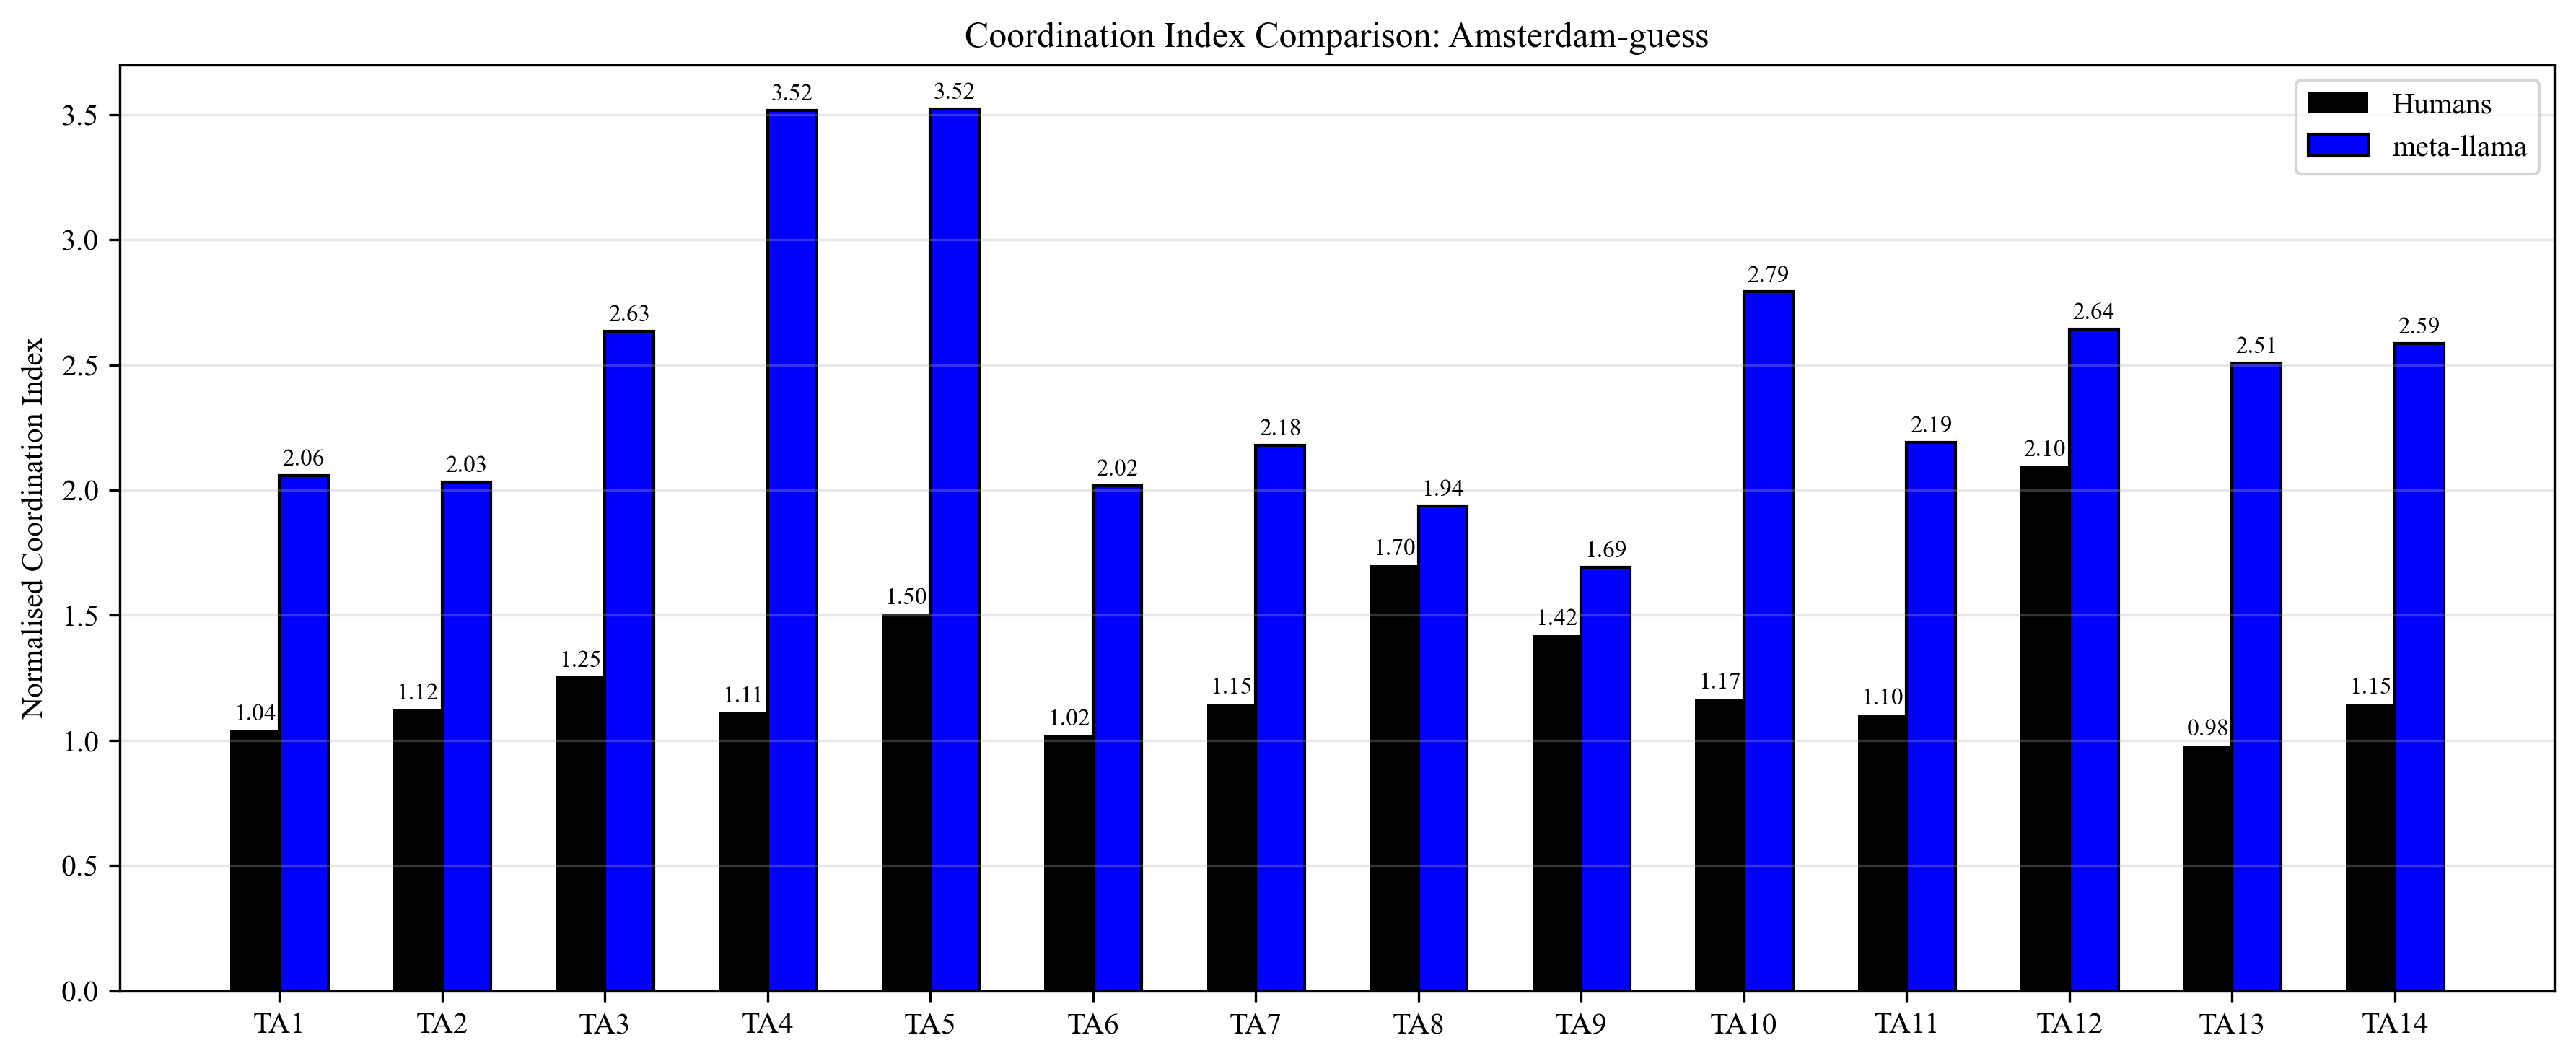

Label: coordinate
14
{'walking': 67, 'sitting': 23}
[2.1398252184769038, 1.6878901373283395, 2.6491885143570535, 3.1860174781523094, 2.651685393258427, 2.3470661672908864, 1.7540574282147317, 2.8439450686641696, 2.0024968789013733, 2.7166042446941323, 1.7540574282147317, 2.922596754057428, 2.083645443196005, 3.076154806491885]
14


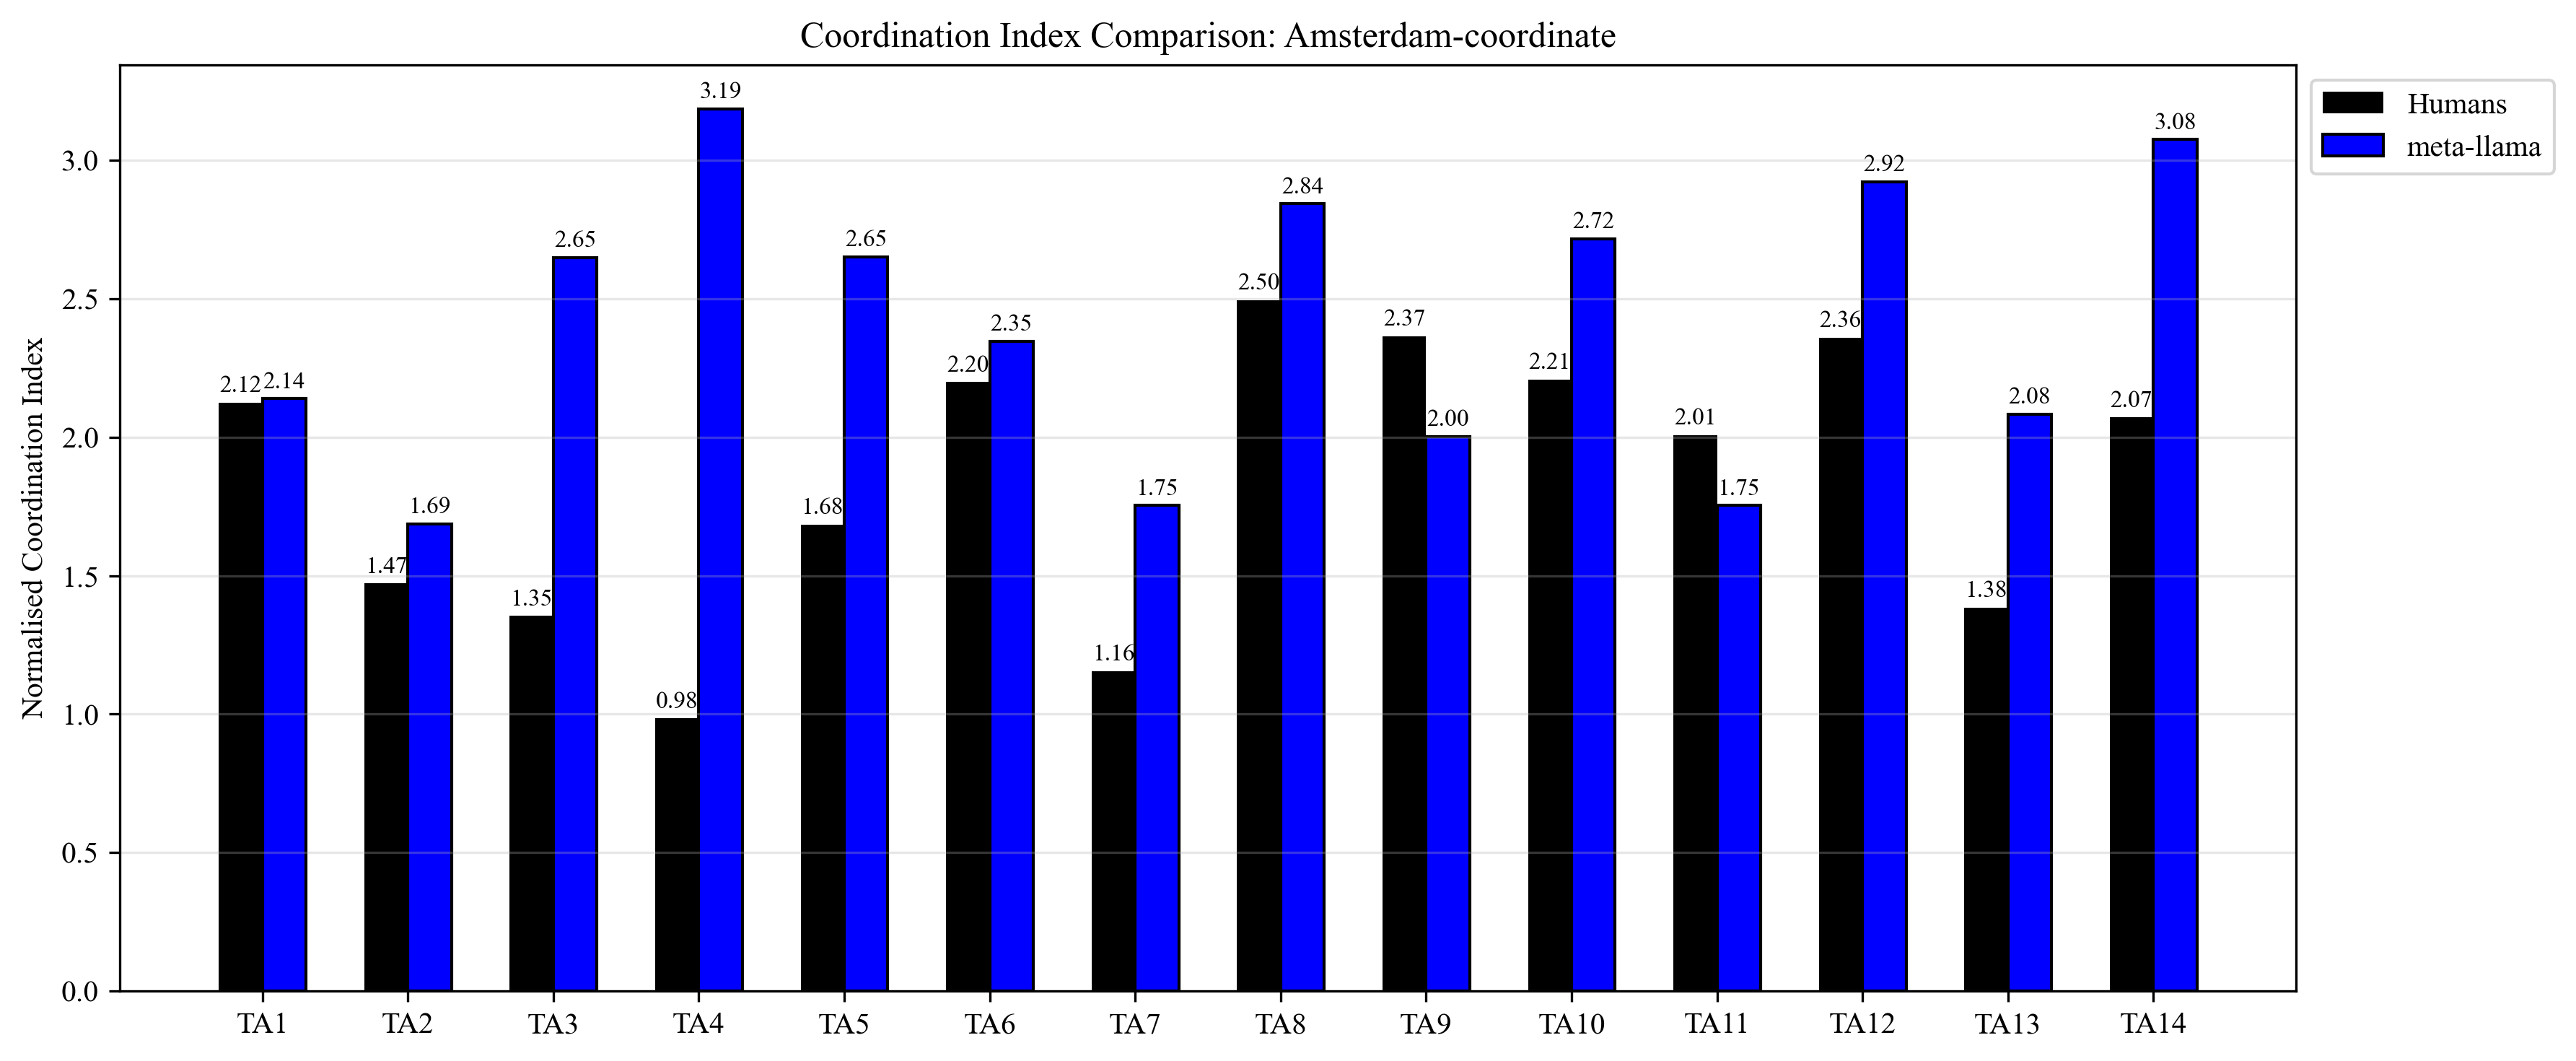

Dataset: nottingham
Label: pick
14
{'prague': 9, 'paris': 73, 'rome': 8}
[1.1697877652933832, 1.7293233082706767, 3.140096618357488, 1.7253433208489388, 1.9444444444444444, 3.091136079900125, 1.6542443064182195, 4.692460317460317, 1.6851265822784811, 1.4756554307116105, 1.7428214731585518, 1.6754057428214733, 1.1535580524344569, 3.3607990012484397]
14


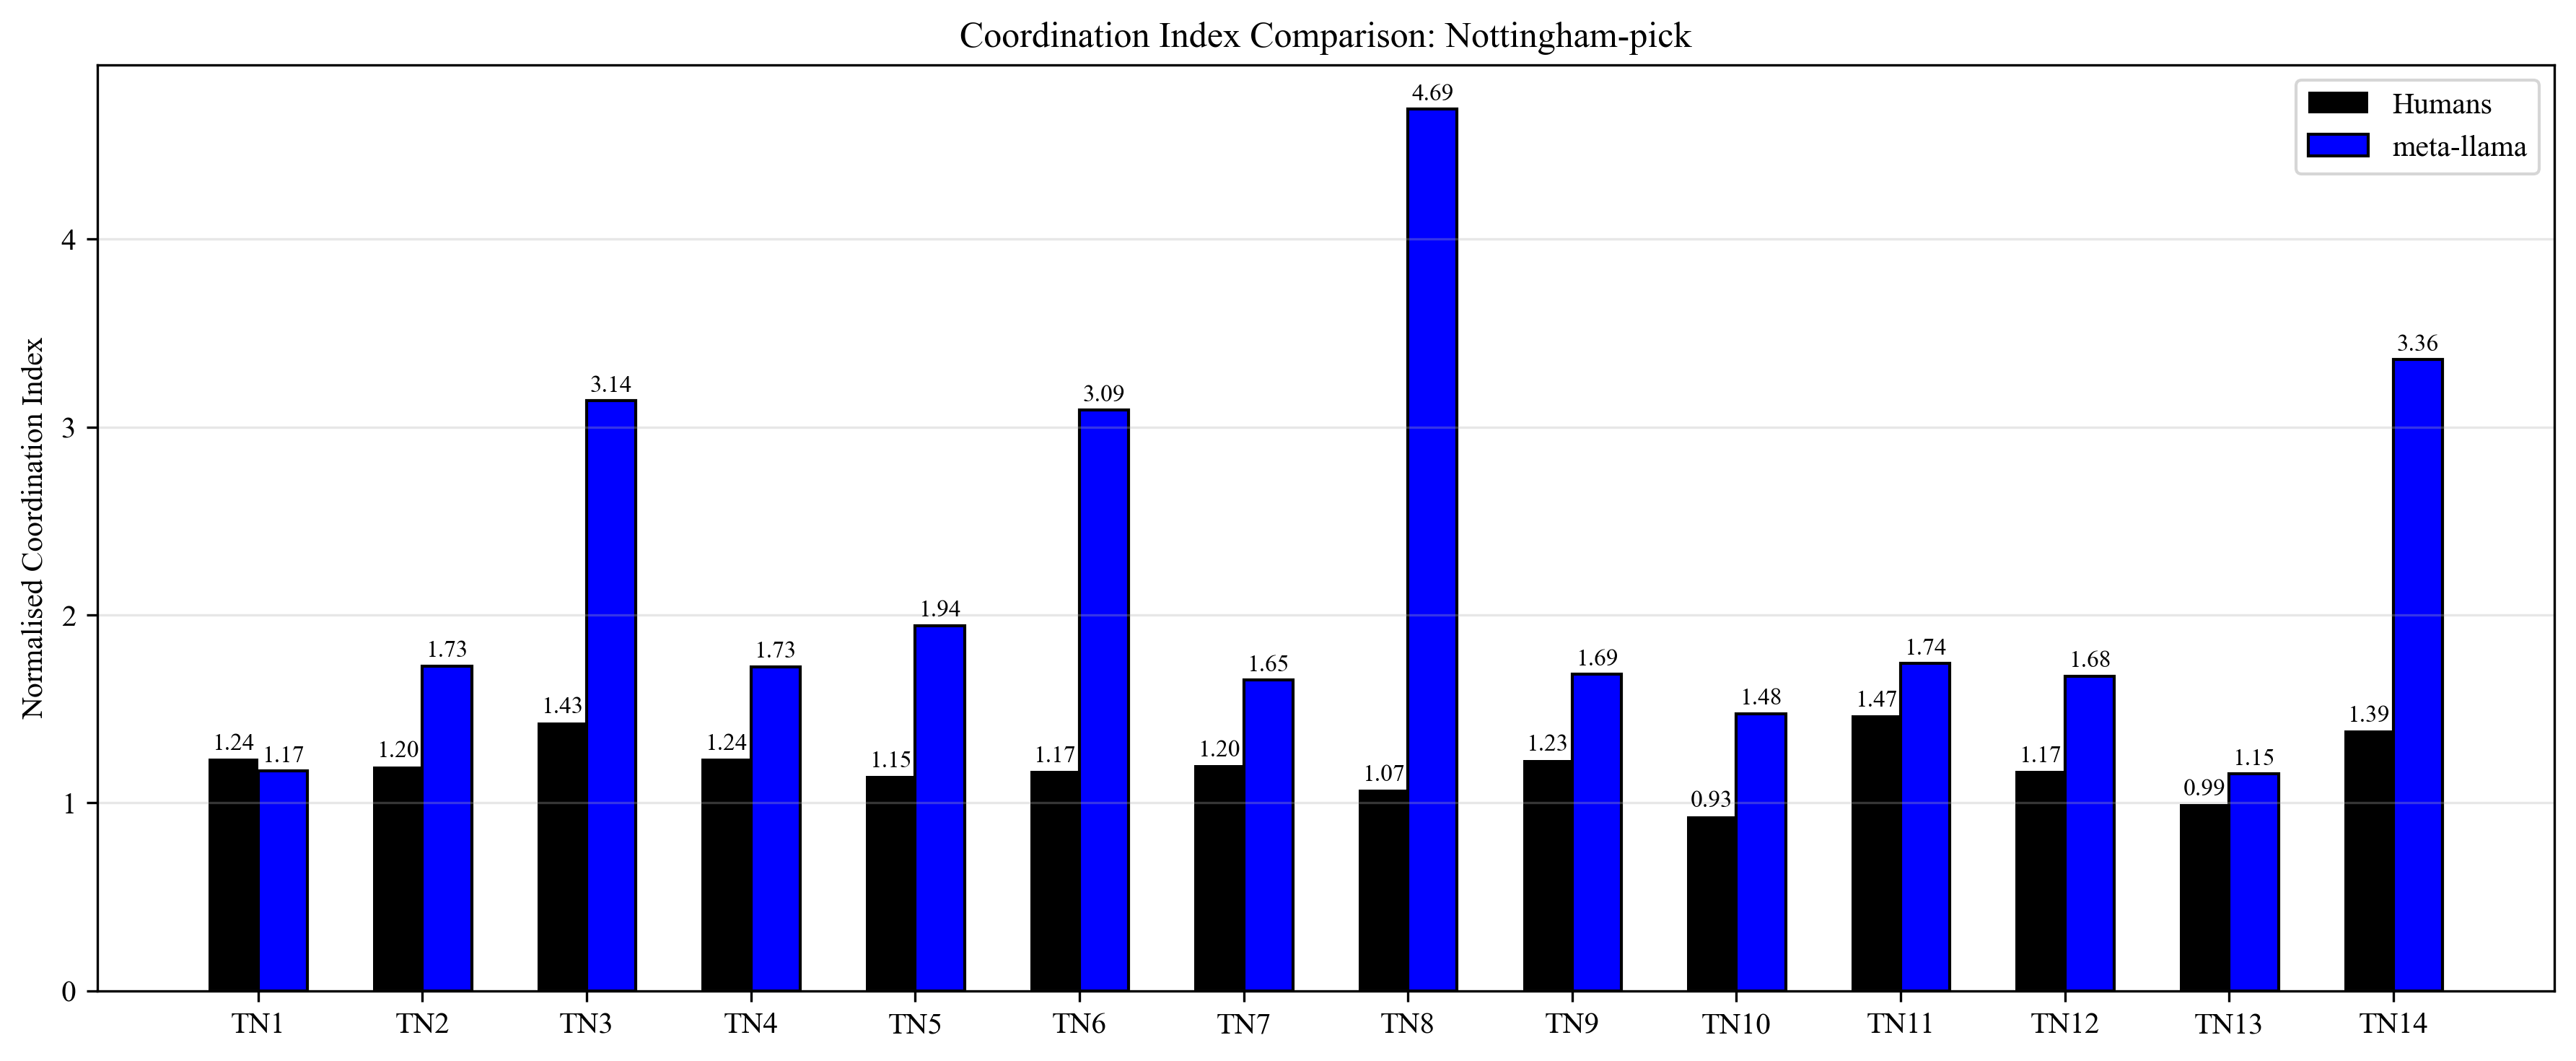

Label: guess
14
{'paris': 69, 'prague': 14, 'rome': 4, 'calais': 3}
[1.0024968789013733, 1.637952559300874, 3.0611735330836454, 2.0, 1.2343260188087775, 3.6416978776529336, 1.4856429463171037, 1.515605493133583, 1.328011611030479, 1.525593008739076, 1.3108614232209739, 2.504369538077403, 1.3957553058676655, 3.0536828963795255]
14


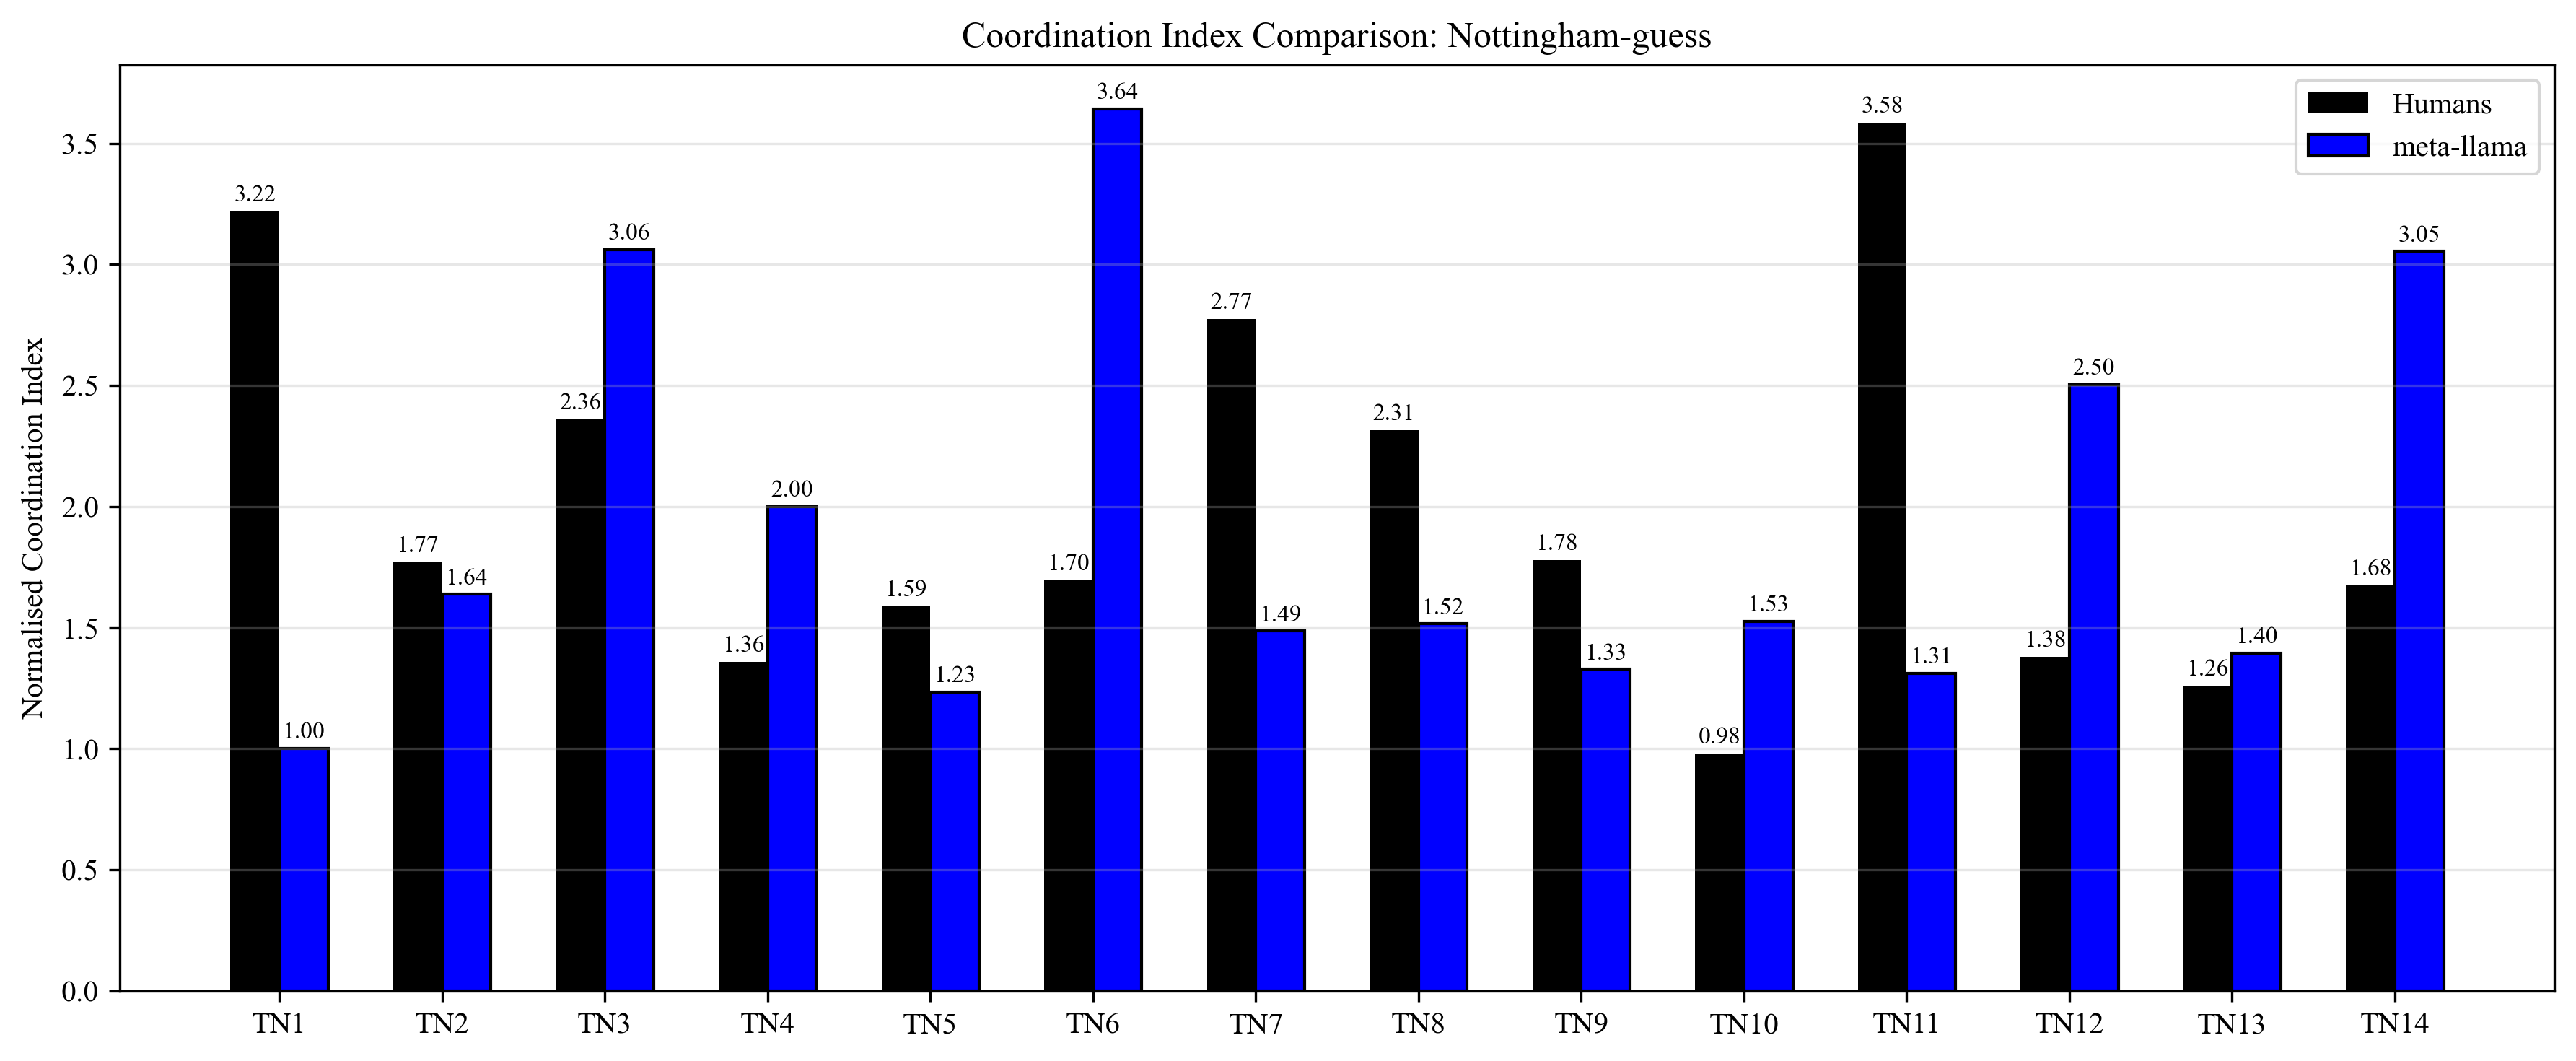

Label: coordinate
14
{'paris': 89, 'prague': 1}
[1.042446941323346, 2.3641456582633054, 4.370786516853933, 2.8601747815230962, 1.1474469305794608, 5.0, 1.260923845193508, 2.822509550396709, 1.8720657276995305, 1.5018726591760299, 1.4207240948813982, 2.6491885143570535, 1.7265917602996255, 4.888888888888889]
14


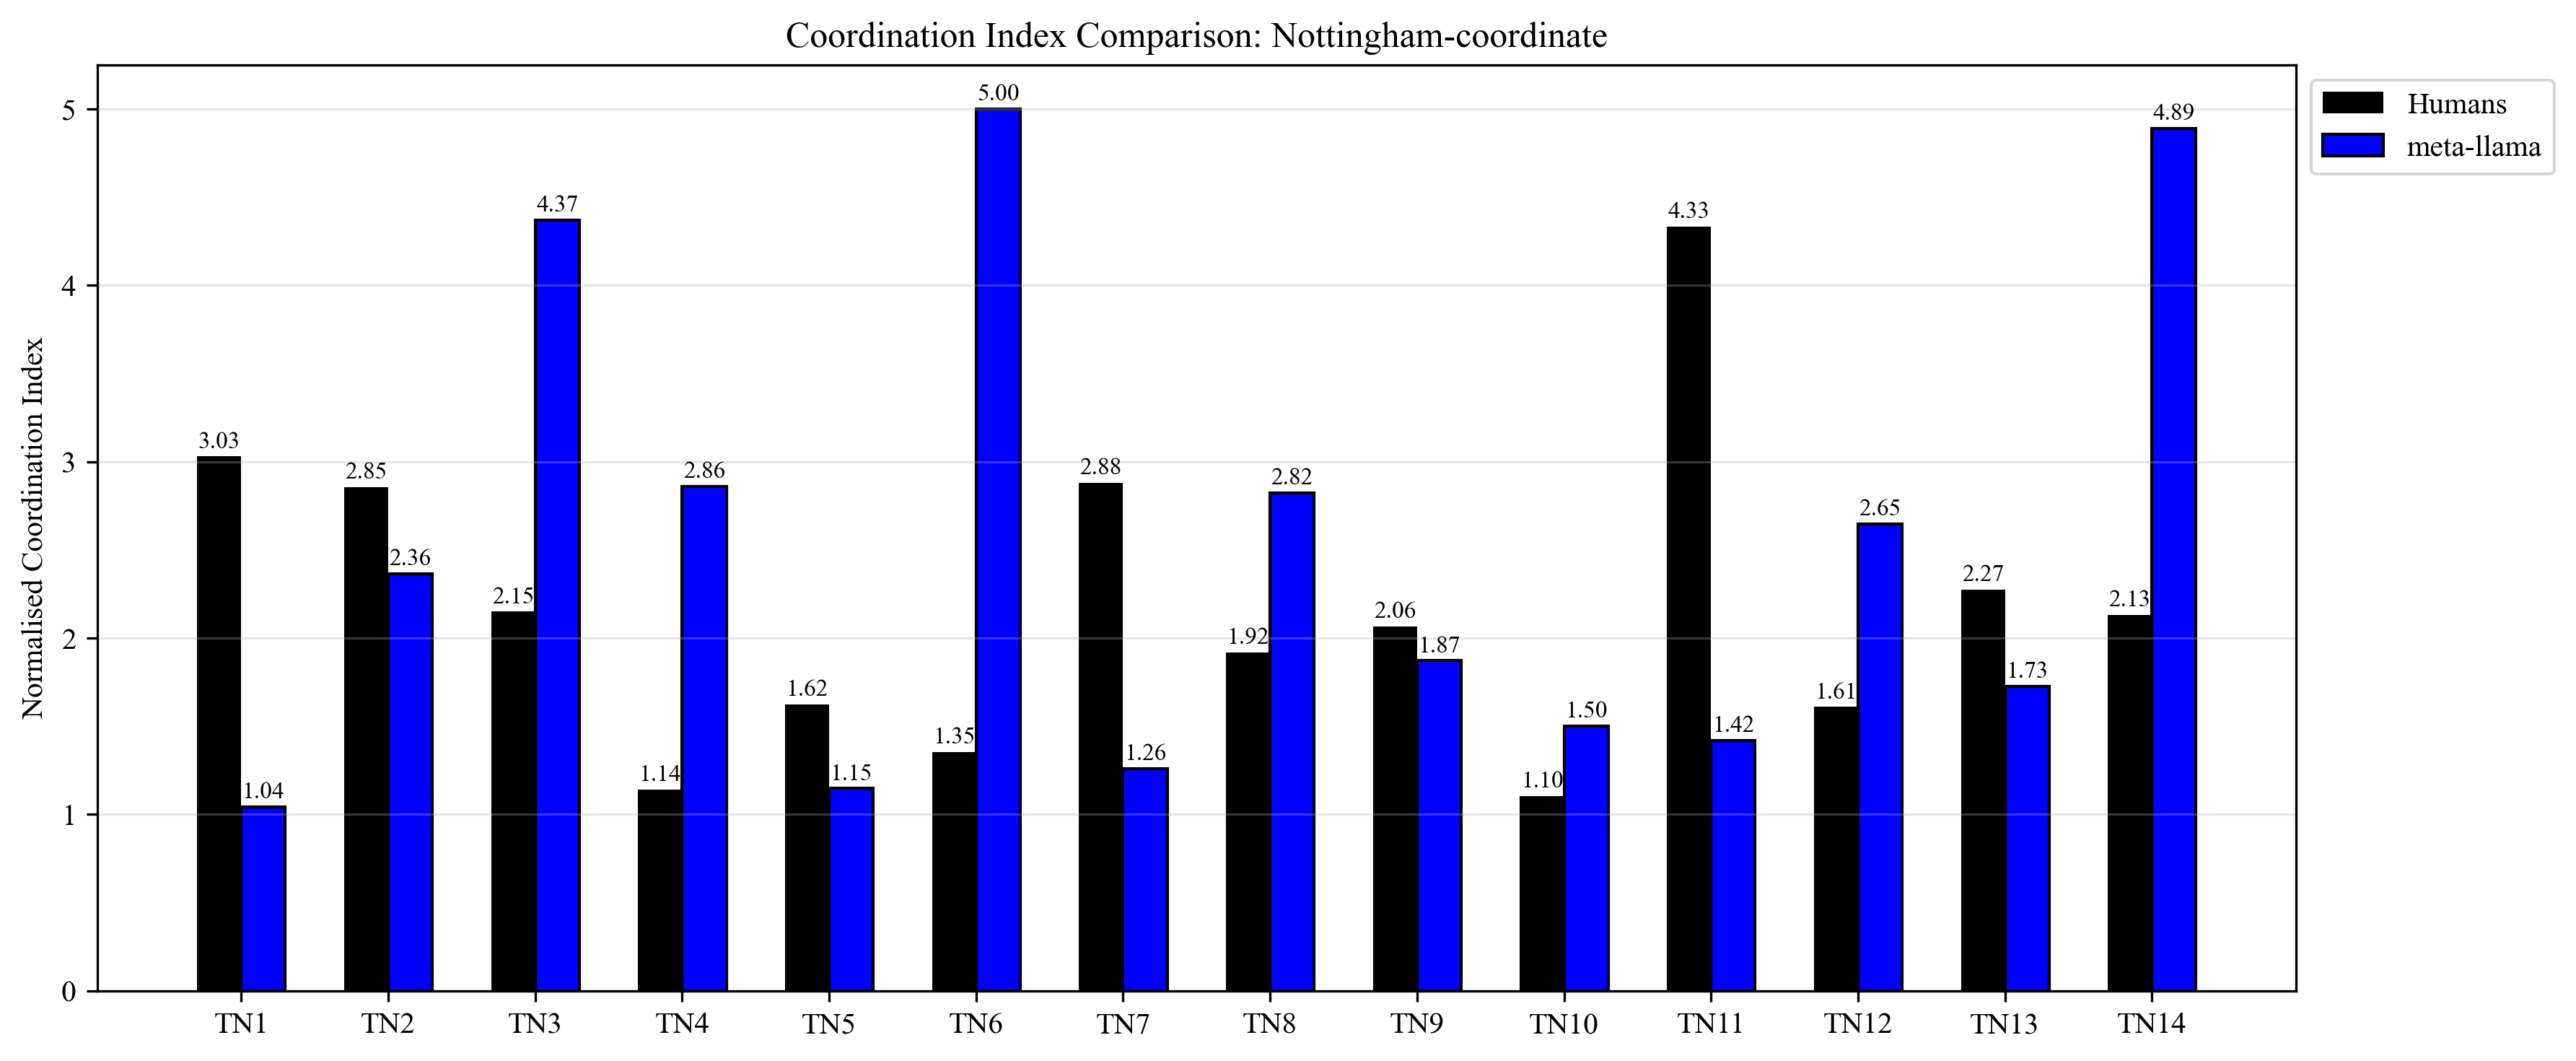

Dataset: amsterdam
Label: pick
14
{'walking': 26, 'jogging': 4}
[1.5977011494252873, 2.5172413793103448, 3.1494252873563218, 5.0, 2.5977011494252875, 2.6206896551724137, 2.0, 2.2528735632183907, 1.6091954022988506, 2.0, 2.5172413793103448, 4.666666666666667, 1.632183908045977, 3.8045977011494254]
14


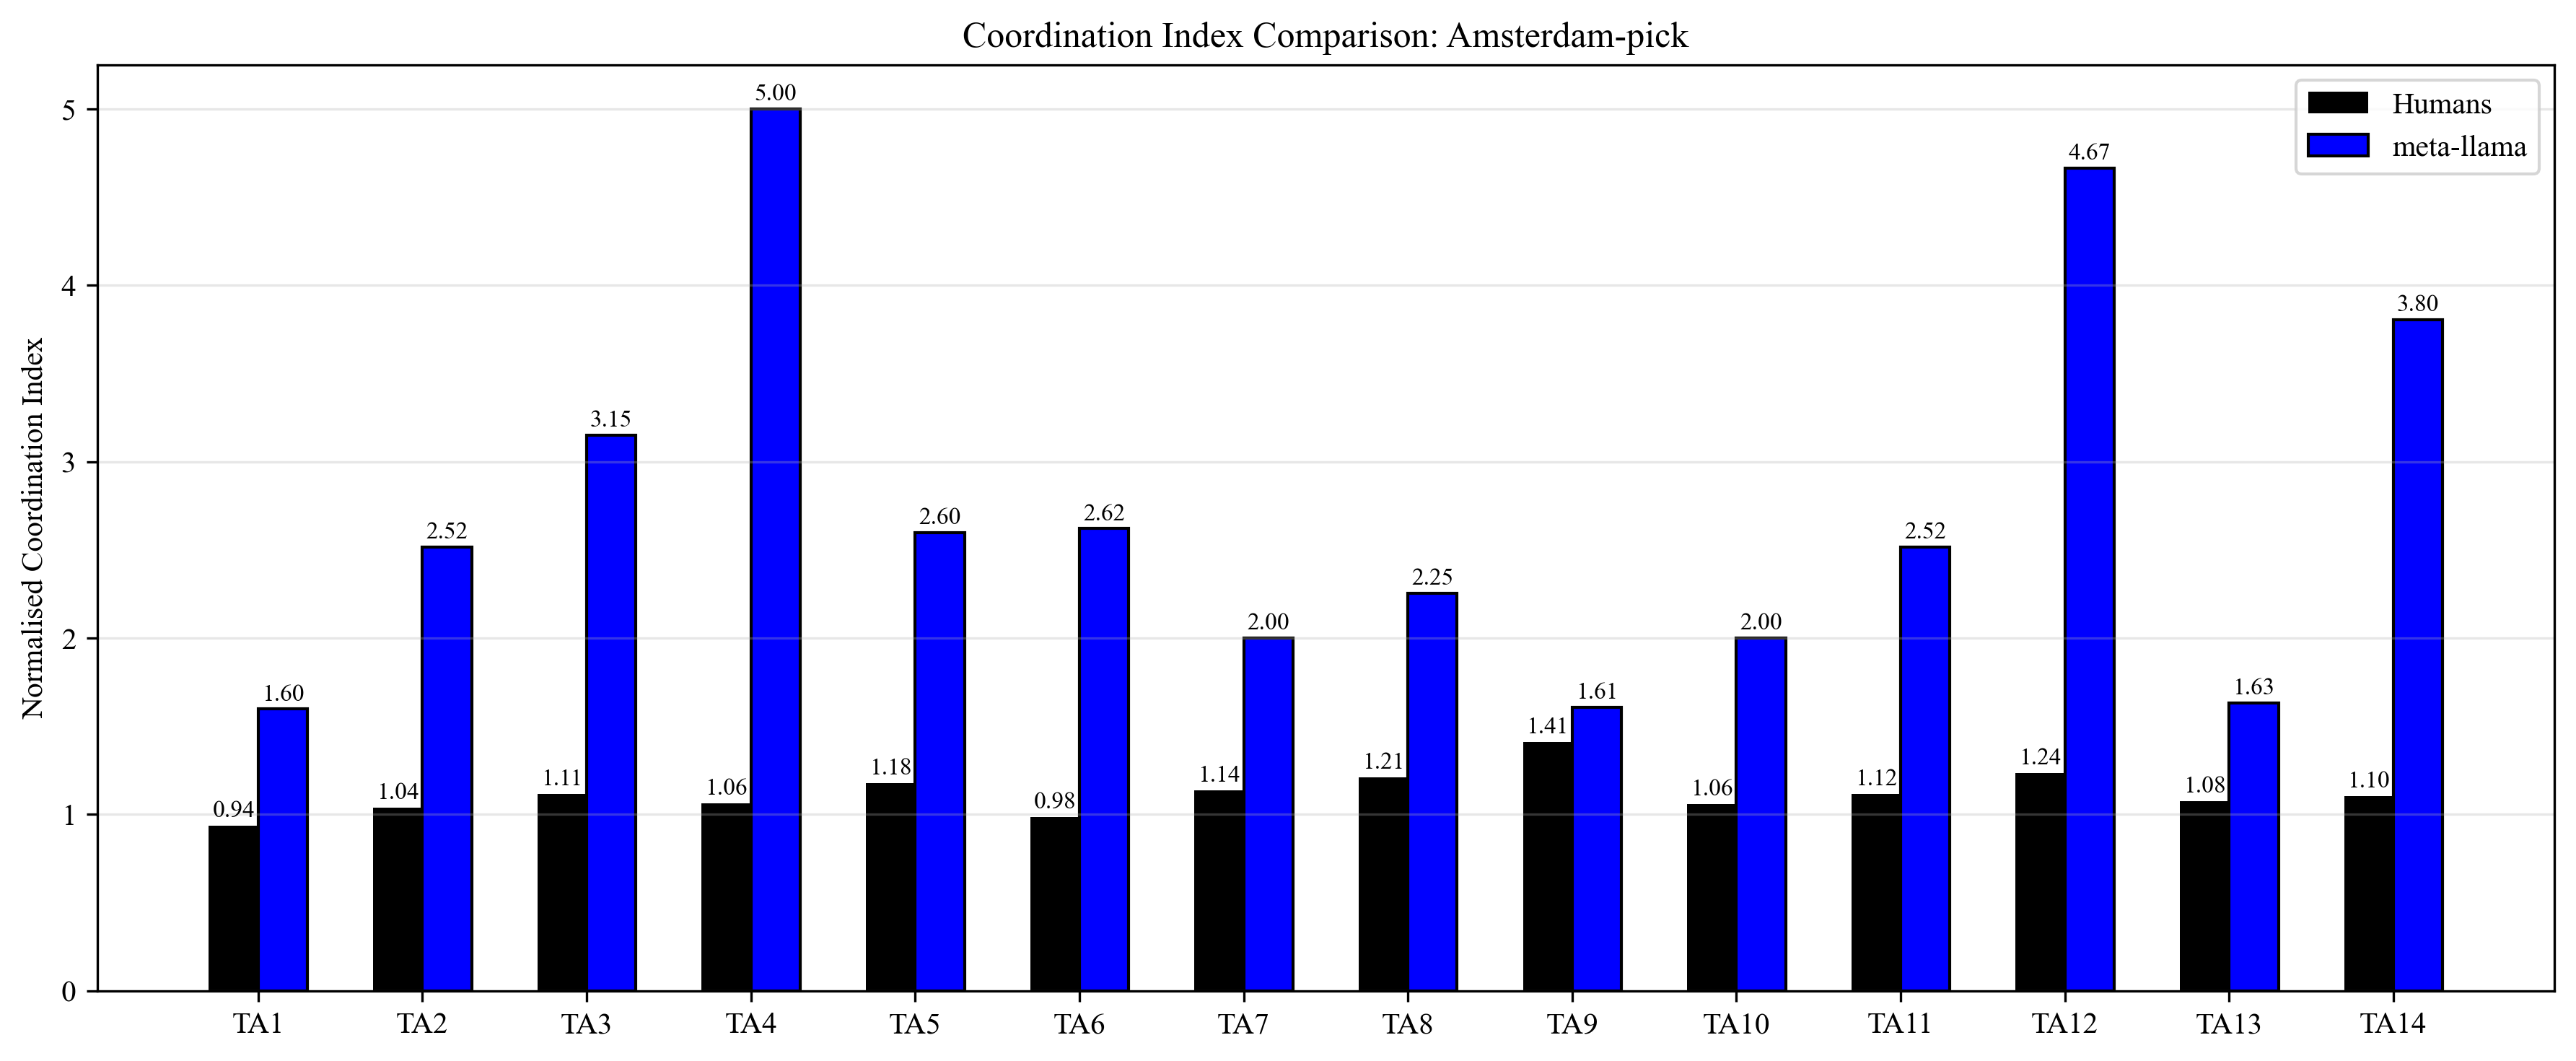

Label: guess
14
{'walking': 28, 'jogging': 2}
[1.5517241379310345, 3.5632183908045976, 2.5172413793103448, 3.5172413793103448, 4.068965517241379, 1.735632183908046, 2.2528735632183907, 2.2528735632183907, 1.7816091954022988, 2.9770114942528734, 2.5977011494252875, 3.1494252873563218, 2.7011494252873565, 4.35632183908046]
14


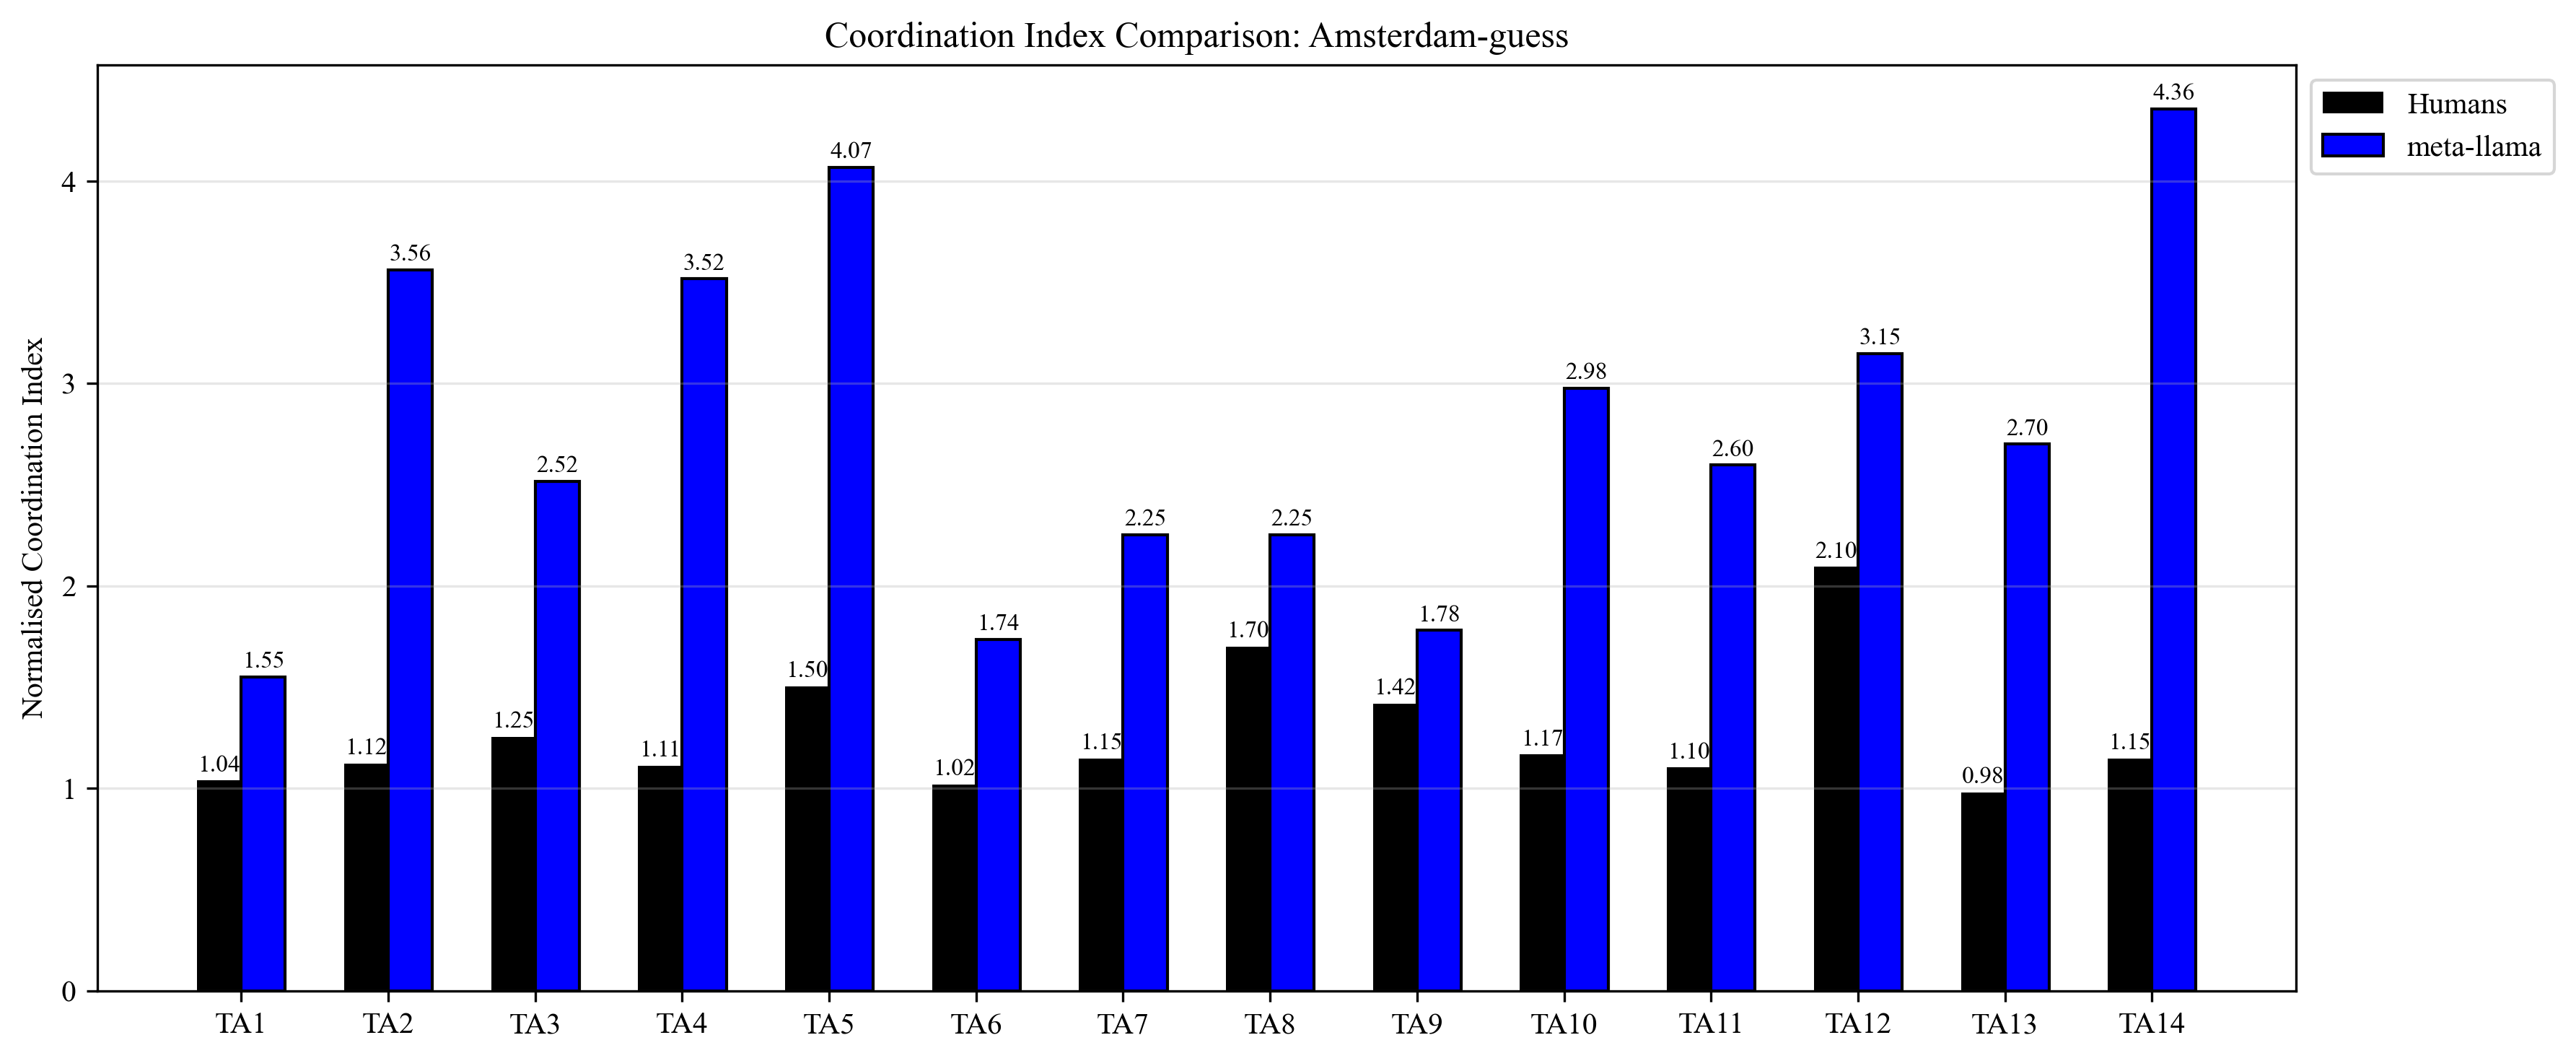

Label: coordinate
14
{'walking': 30}
[1.9195402298850575, 2.7011494252873565, 2.6666666666666665, 3.5632183908045976, 2.9770114942528734, 2.839080459770115, 2.0, 4.35632183908046, 3.2873563218390807, 2.735632183908046, 2.425287356321839, 3.1494252873563218, 2.8275862068965516, 5.0]
14


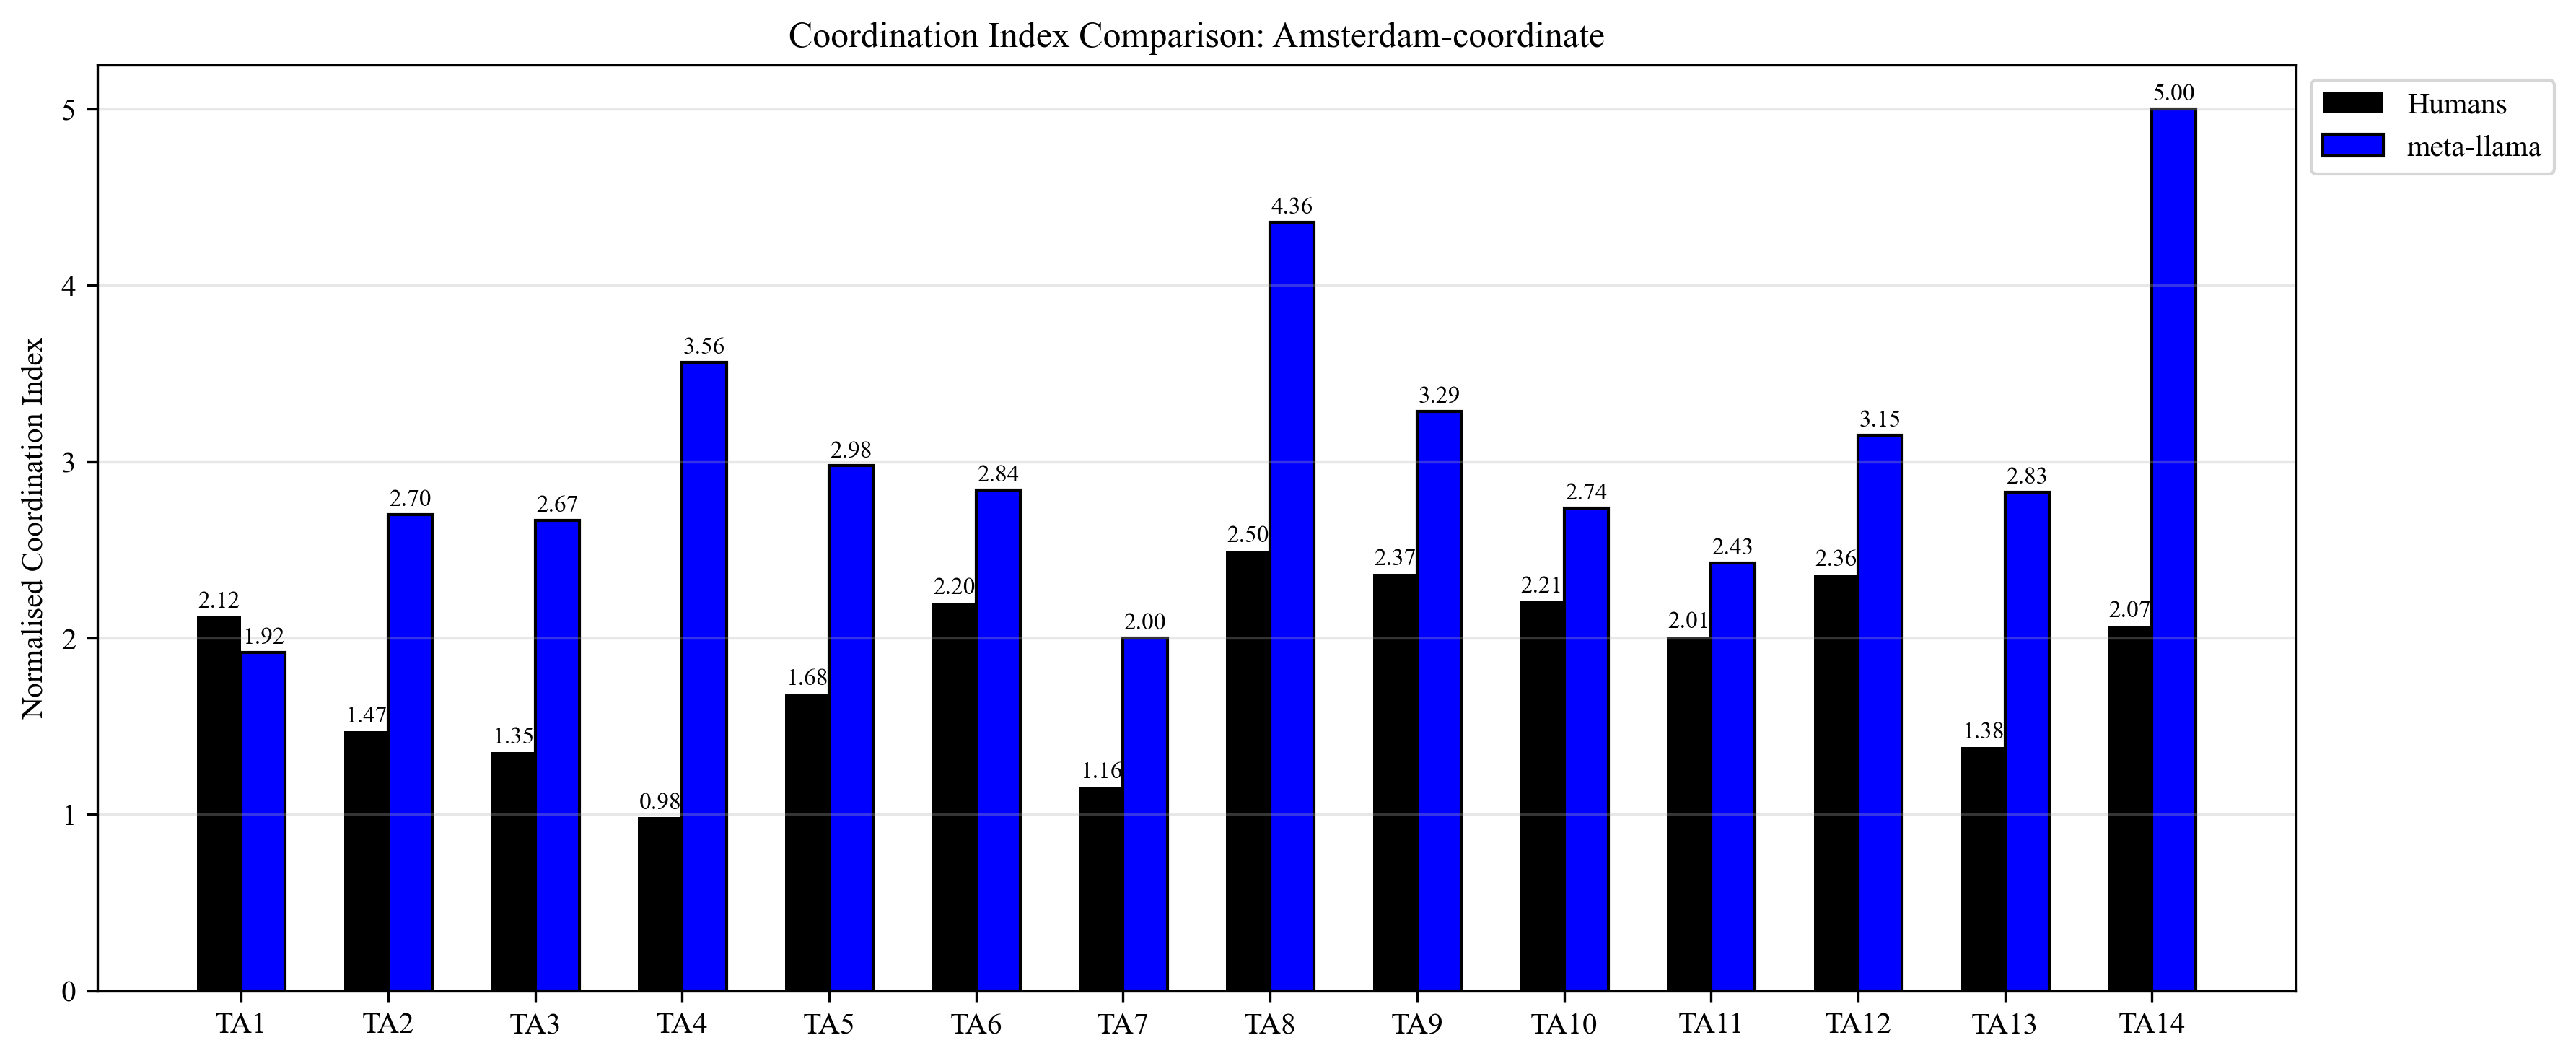

Dataset: nottingham
Label: pick
14
{'rome': 8, 'paris': 18, 'prague': 4}
[1.0114942528735633, 1.2857142857142858, 5.0, 3.2873563218390807, 2.8853754940711465, 3.8045977011494254, 5.0, 5.0, 2.95, 2.160919540229885, 1.632183908045977, 4.068965517241379, 1.1724137931034482, 2.1494252873563218]
14


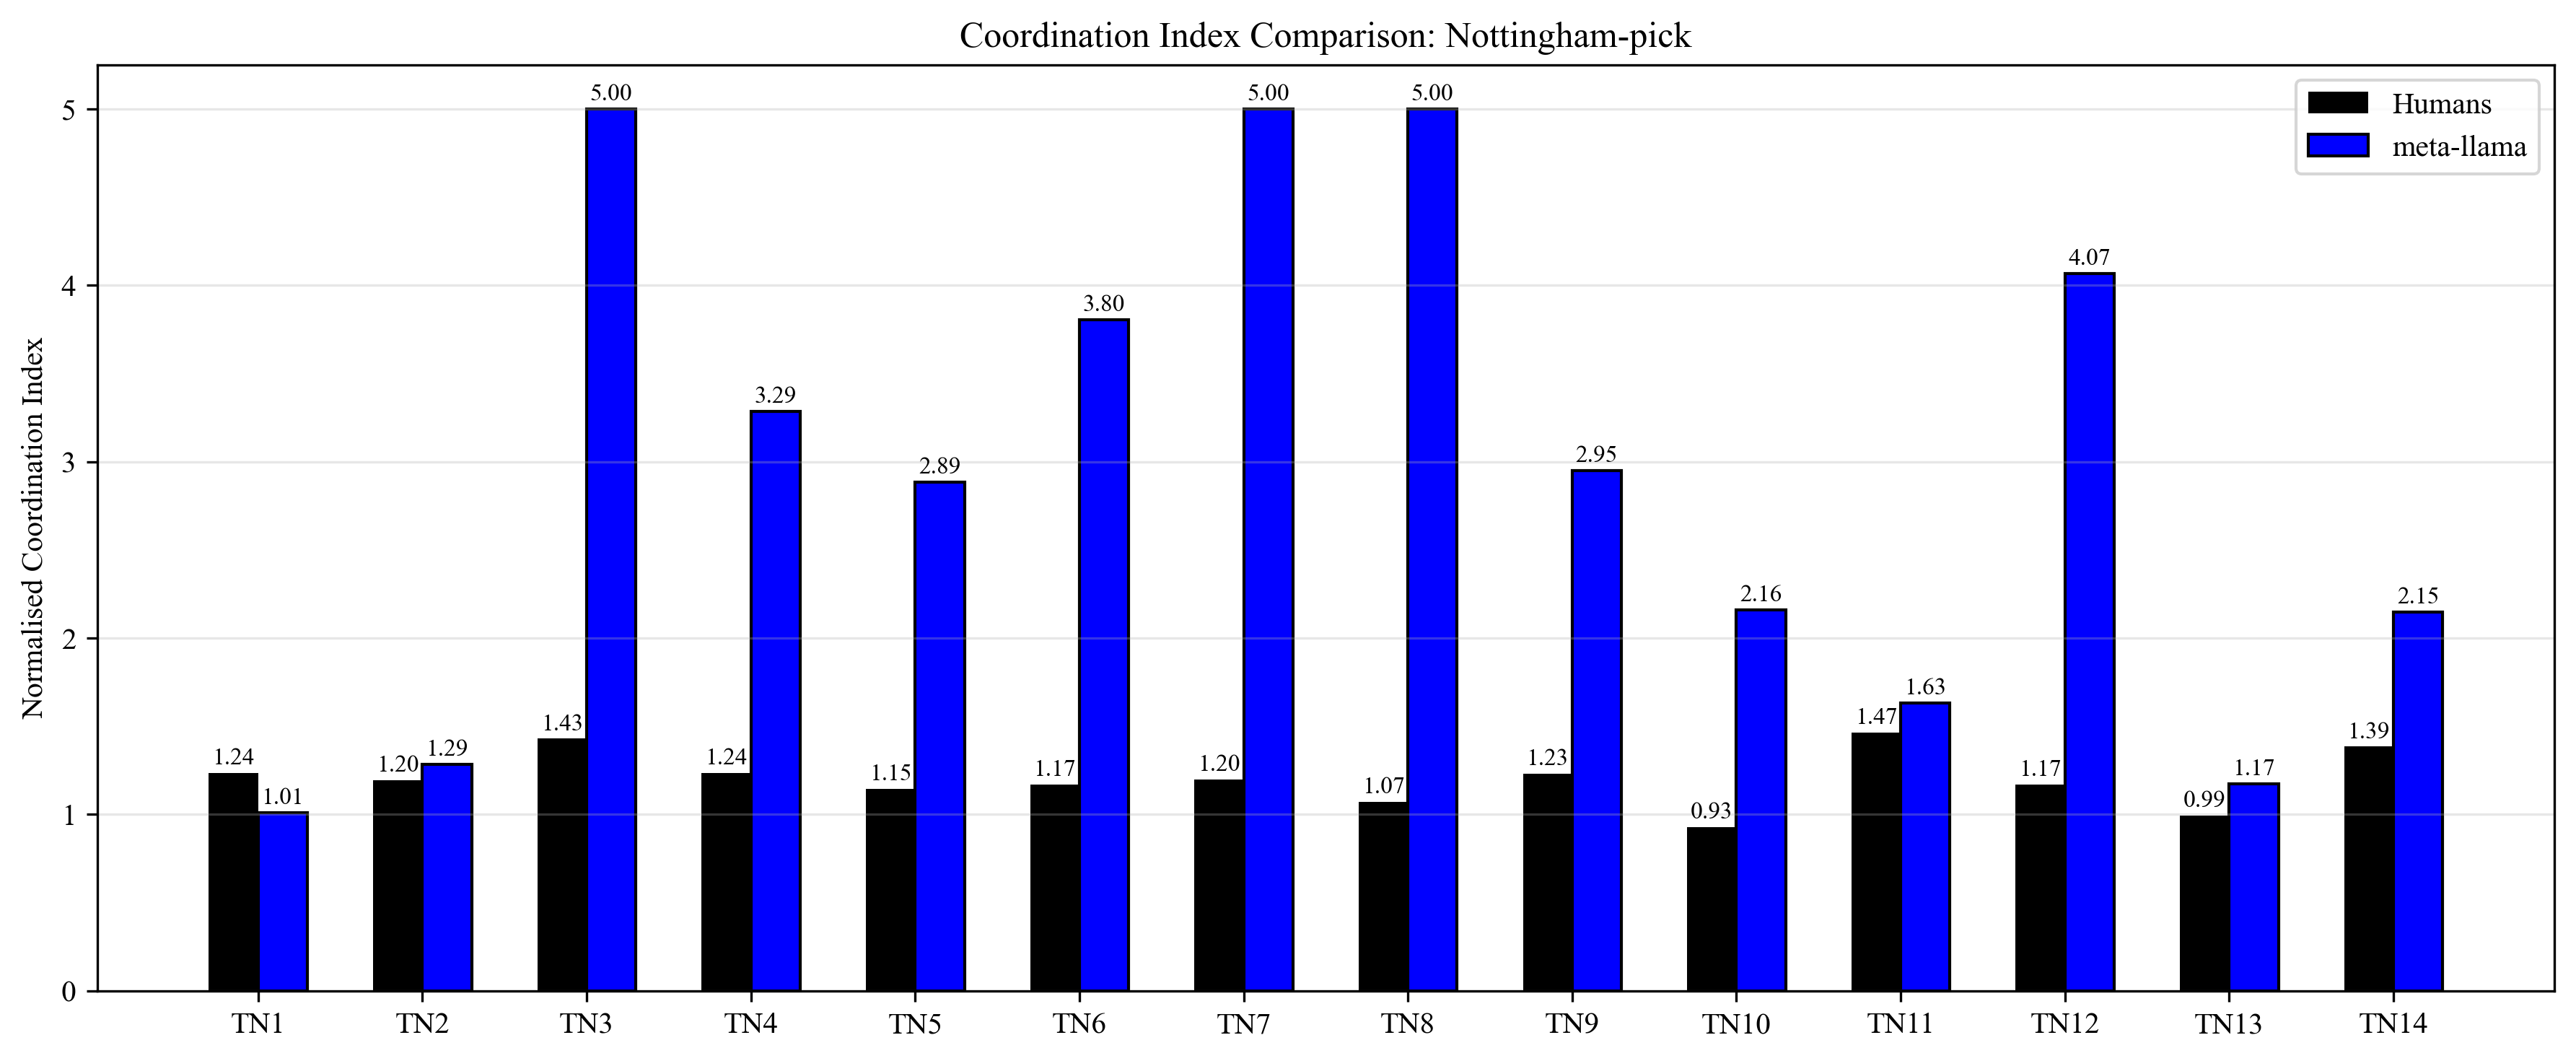

Label: guess
14
{'paris': 29, 'prague': 1}
[1.6551724137931034, 1.793103448275862, 2.9770114942528734, 1.6781609195402298, 2.2988505747126435, 2.9770114942528734, 5.0, 3.4942528735632186, 1.2857142857142858, 1.6781609195402298, 1.3563218390804597, 2.0919540229885056, 2.0, 4.666666666666667]
14


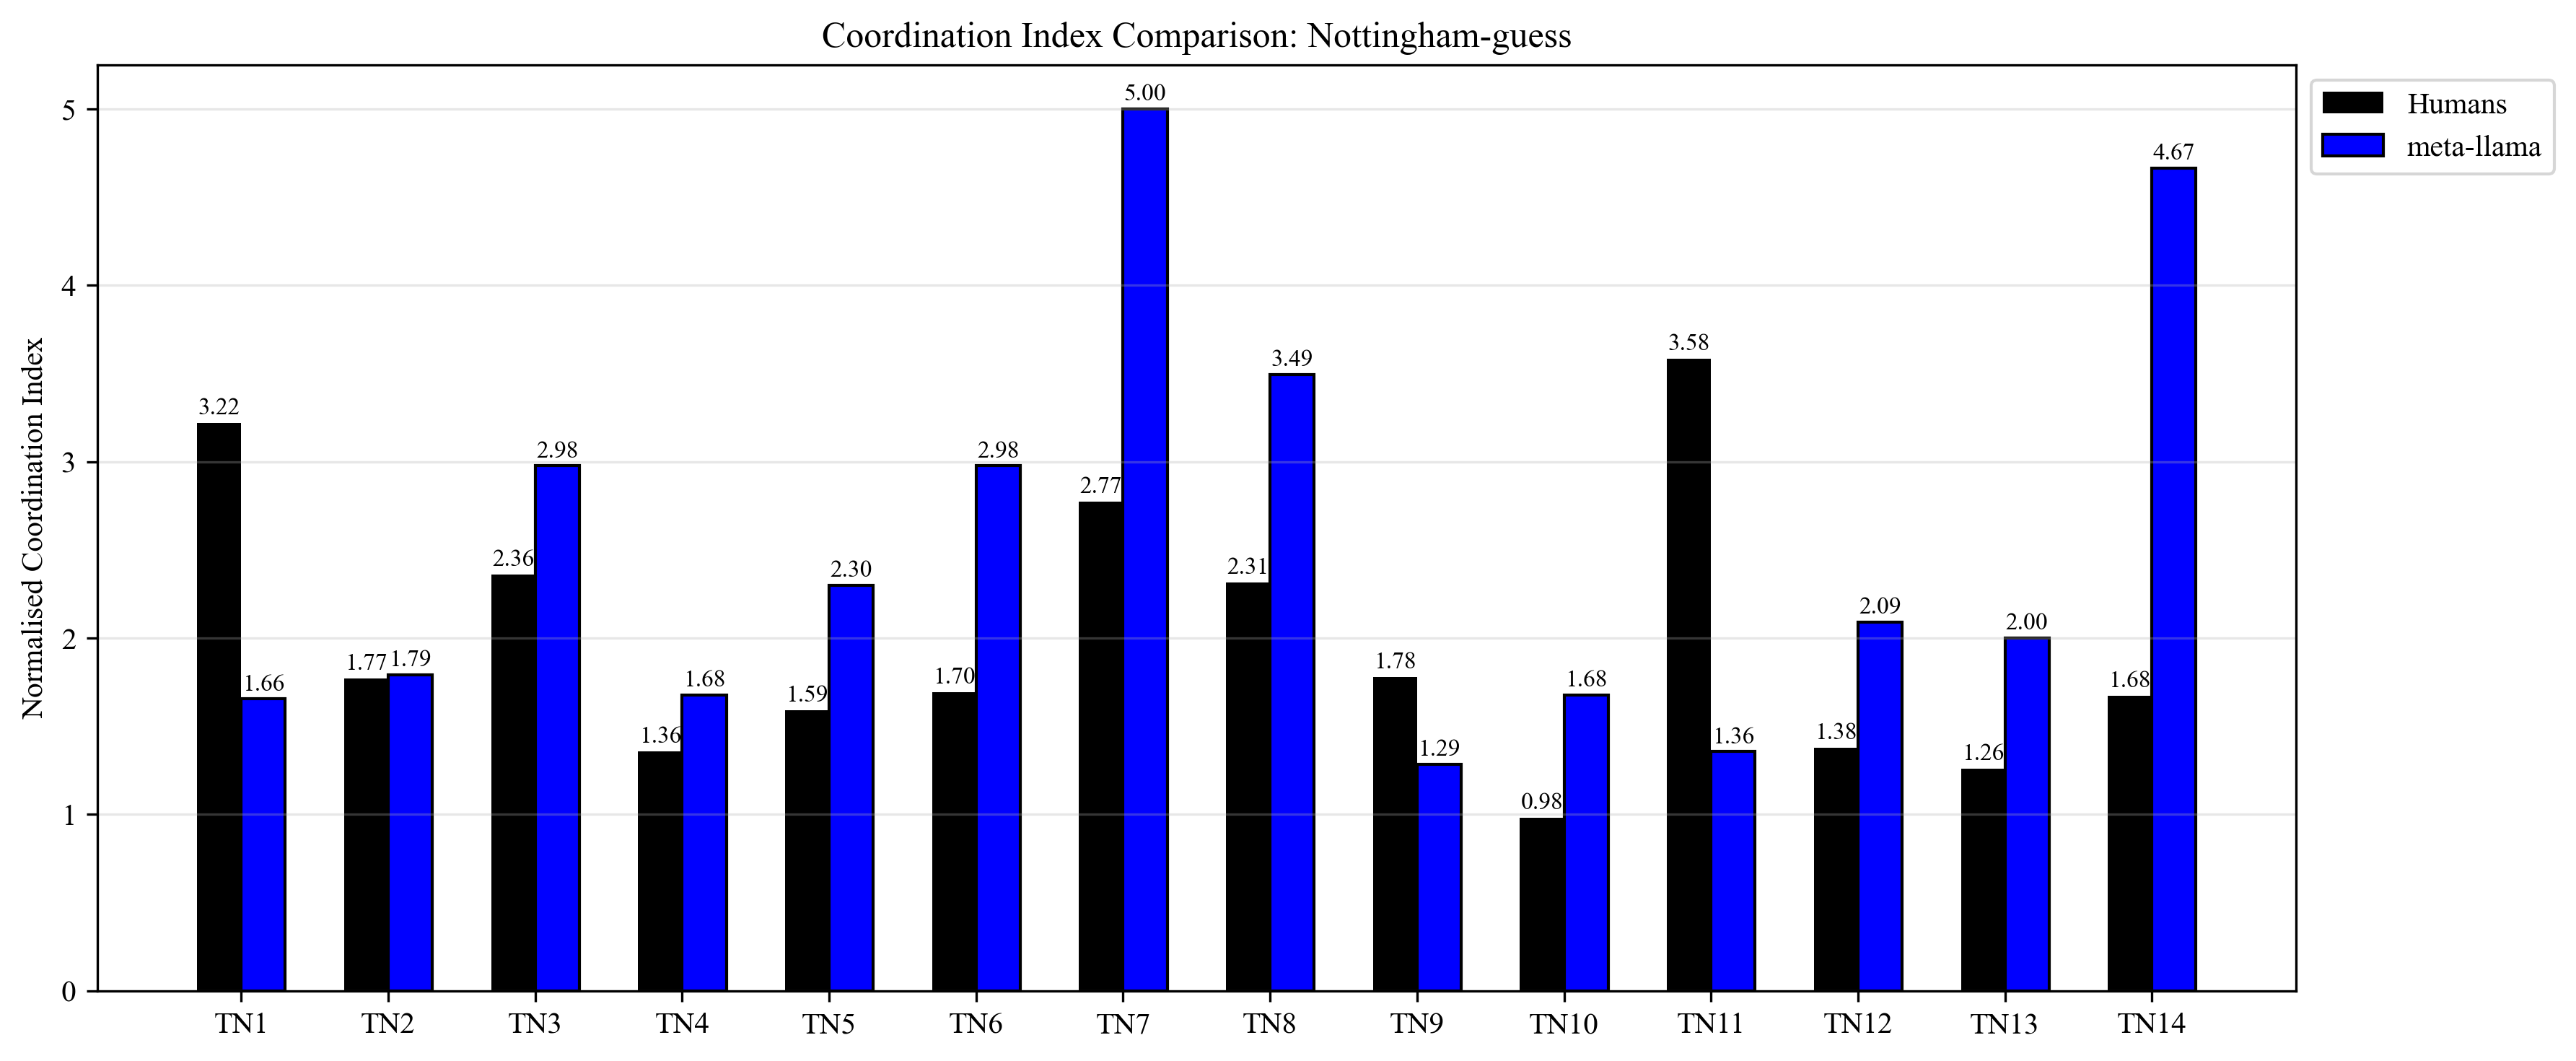

Label: coordinate
14
{'paris': 30}
[1.0, 2.2354497354497354, 5.0, 4.0344827586206895, 2.261904761904762, 5.0, 1.839080459770115, 4.35632183908046, 2.7450980392156863, 2.367816091954023, 1.4252873563218391, 2.6666666666666665, 1.6436781609195403, 5.0]
14


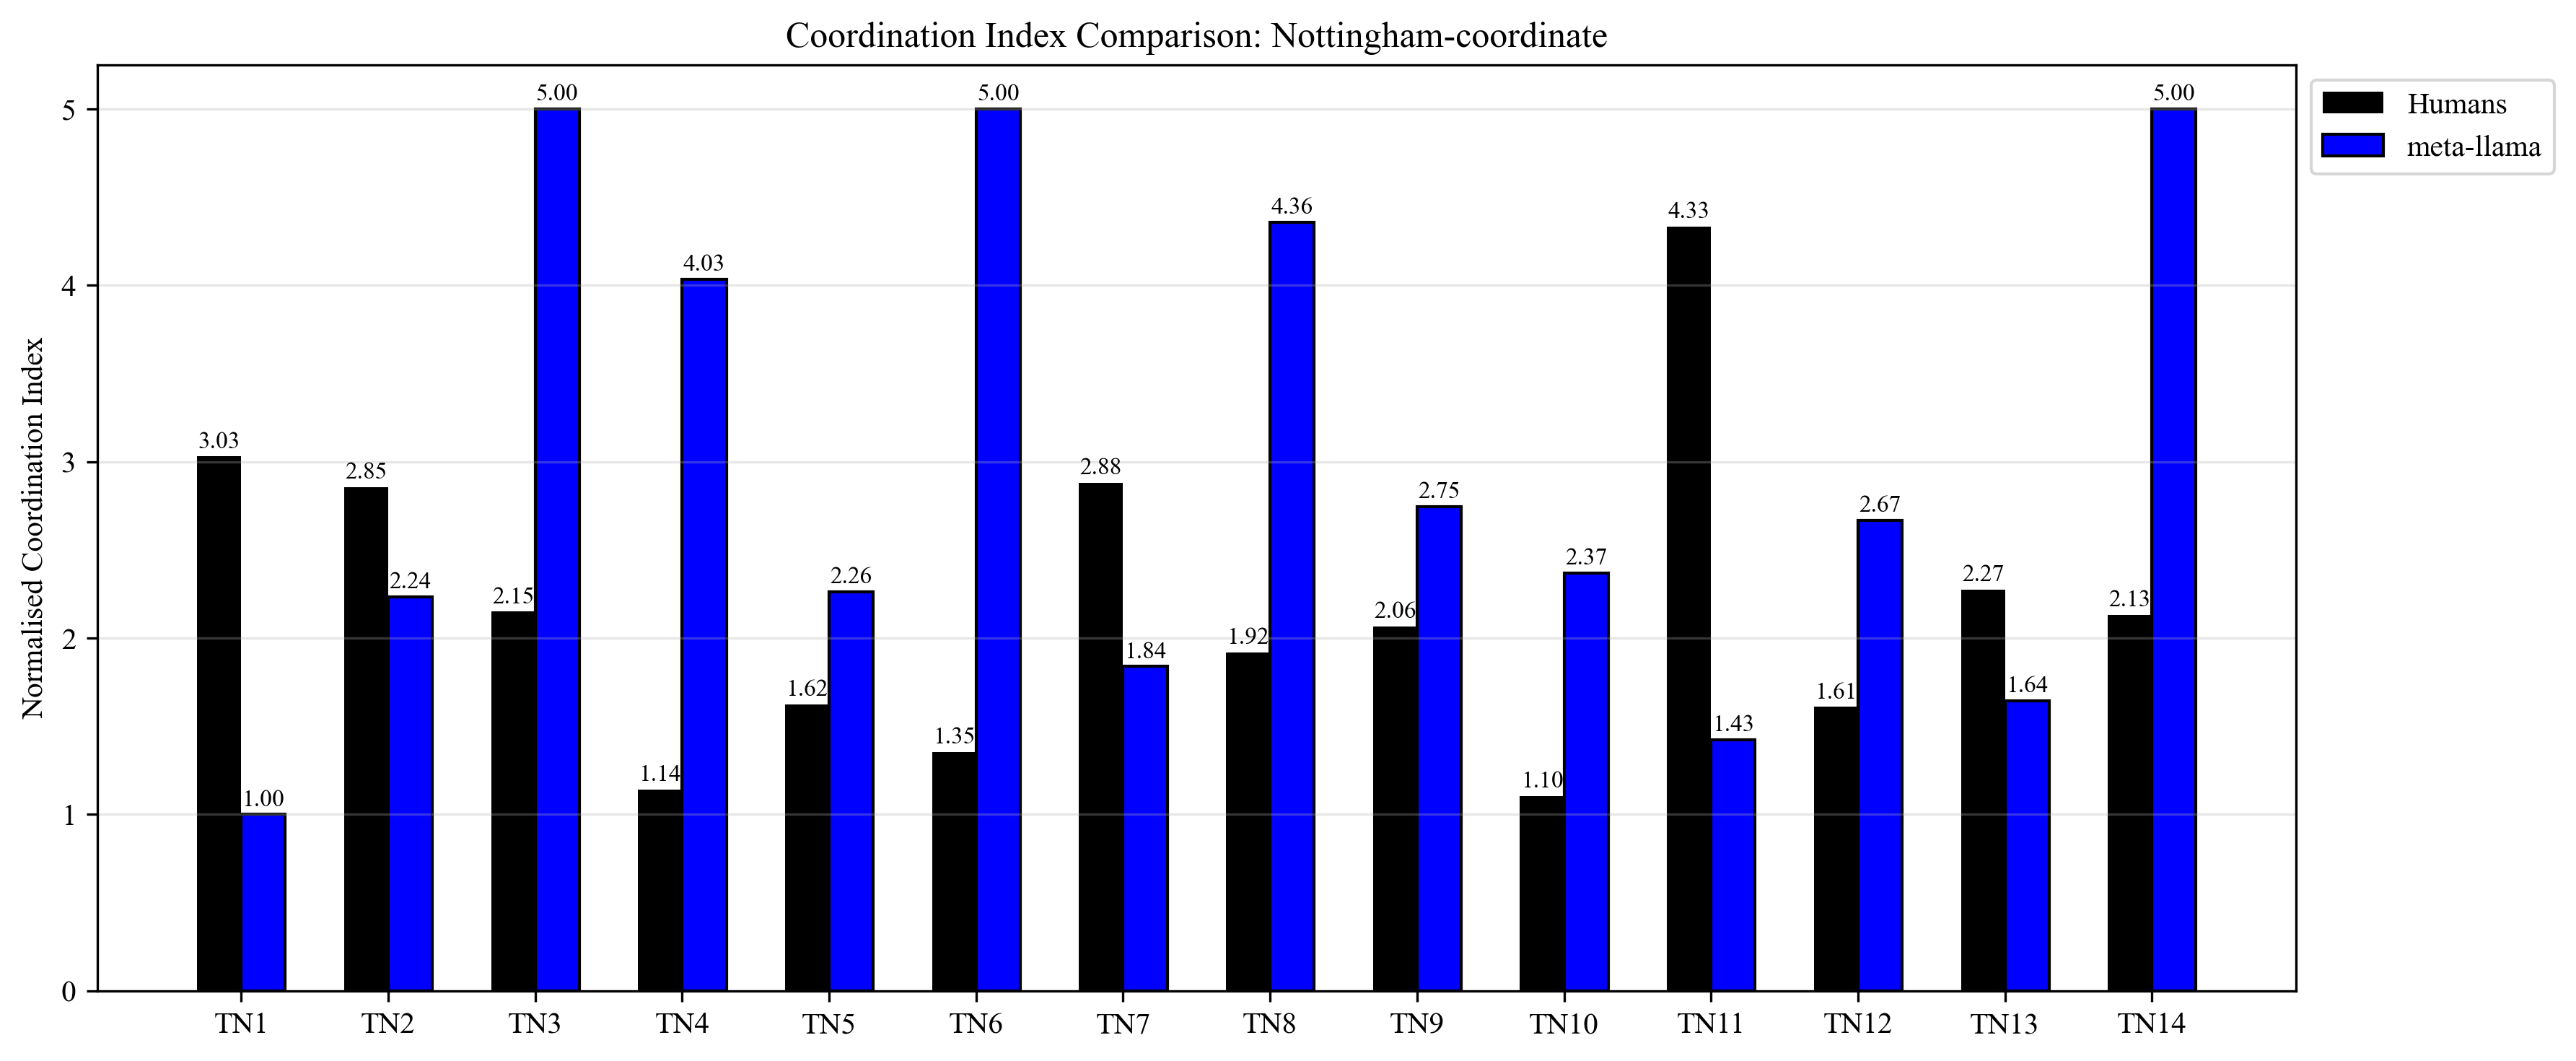

In [17]:
        
# 3. Coordination Index -- Merge best llamas
model_names = [
    "/meta-llama/Llama-3.1-70B-Instruct"
                ]
    
for suffix, mega_i in [("-all-variations", 3), ("-first-variation", 1)]:  
    for d_name in dataset_names:
        print(f"Dataset: {d_name}")
        # Load the human results (we need them for the normalisation factor)
        with open(f"./data/{d_name}.jsonl", "r") as f:
            data_humans = json.load(f)
        normalization_factors = [d["normalization_factor"] for d in data_humans]
        
        for l in labels:
            data_llms = []
            print(f"Label: {l}")

            # Load LLM results
            for i in range(0, len(data_humans)*3, 3):  # TA
                current_responses = {}
                for model_name in model_names:
                    with open(f"./results{model_name}/{d_name}_problem-{l}.jsonl", "r") as f:
                        data_llm = json.load(f)
                    
                    for d in data_llm[i:i+mega_i]:
                        # For each task, put together the tasks and then average
                        for response in d["responses"].keys():
                            match = re.search(r"<answer>(.*?)</answer>", response, re.DOTALL)

                            if match:
                                re_response = match.group(1).strip().lower()
                                if re_response not in current_responses:
                                    current_responses[re_response] = 0
                                current_responses[re_response] += d["responses"][response]
                    
                # Normalised coordination index
                current_responses = sample(current_responses, n=num_samples, replacement=sample_with_replacement)
                N = sum(list(current_responses.values()))
                n = normalization_factors[i%3]
                nci = 0.
                if N > 1:
                    for _,v in current_responses.items():
                        nci += v*(v-1)
                    data_llms.append(nci*n/(N*(N-1)))
                else:
                    data_llms.append(0.)

            # Load Human results
            with open(f"./data/Bardsley-humans/{d_name}.jsonl", "r") as f:
                results_humans = json.load(f)
            current_data_humans = [
                dd["normalised_coordination_index"] for dd in results_humans if dd["task"] == l
            ]

            # ---- Plot ----
            plt.figure(figsize=(12, 5))

            tasks = [f"T{d_name[0].upper()}{i+1}" for i in range(14)]
            x = np.arange(len(tasks))  # label locations
            width = 0.3  # width of each bar

            # Plot human data (shifted left)
            human_bars = plt.bar(x - width/2, current_data_humans, width, label="Humans", color="black")

            # Plot meta-llama data (shifted right)
            llm_bars = plt.bar(x + width/2, data_llms, width, label="meta-llama", color="blue", edgecolor="black")

            # Add values on top of human bars
            for bar in human_bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', ha='center', va='bottom', fontsize=8)

            # Add values on top of LLM bars
            for bar in llm_bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', ha='center', va='bottom', fontsize=8)

            plt.xticks(x, tasks)
            plt.title(f"Coordination Index Comparison: {d_name.capitalize()}-{l}")
            plt.ylabel("Normalised Coordination Index")
            plt.legend(bbox_to_anchor=(1., 1.))
            plt.tight_layout()
            plt.grid(axis='y', alpha=0.3)
            plt.savefig(SAVEDIR + BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER + f"/{d_name}-{l}{suffix}.png")
            plt.show()

